<h2 style="color:Purple; font-family:; text-align:center;font-size:35px">
  ❁۪ ｡˚ Actividad 2: Análisis Exploratorio de Datos: Titanic ❁۪ ｡˚
</h2>
<h1 style="color:Purple; font-size:13.5px;"> Student: </h1>Ornella Cañellas Arredondo 
<h1 style="color:Purple; font-size:13.5px;"> Rol:  </h1>202387002-1
<h1 style="color:Purple; font-size:13.5px;"> Professor: </h1> Pía Amigo


En esta actividad se usan la base de datos de pasajeros del Titanic para practicar **análisis exploratorio de datos (EDA)**.

El objetivo no es hacer la mayor cantidad posible de gráficos, sino aprender a **usar los datos para responder preguntas**.

<h2 style="color:Pink; font-family:; text-align:center;font-size:25px">
  ❁ Pregunta de investigación ❁
</h2>

<h2 style="color:Pink; font-family:; text-align:center;font-size:17px">
   ¿Qué características de los pasajeros estaban asociadas con la supervivencia en el Titanic? 
</h2>

## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos. 
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas. 
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/


In [249]:
#!pip install seaborn , este comando para instalar seaborn

In [250]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
%matplotlib inline
sns.set_style("white")

In [251]:
#esto es para mejorar la calidad de las imágenes
font = {'size'   : 12}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=10) 
matplotlib.rc('ytick', labelsize=10) 
matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 300

<h2 style="color:Fuchsia; font-family:; text-align:center;font-size:20px">
  ❁ Carga de los datos ❁
</h2>

Cada fila de la base de datos corresponde a **un pasajero**.

Las principales características disponibles son:

- `Survived`: supervivencia, 0 = no, 1 = sí
- `Pclass`: clase del pasajero, 1 = primera, 2 = segunda, 3 = tercera
- `Sex`: sexo
- `Age`: edad
- `SibSp`: número de hermanos/as o cónyuges a bordo
- `Parch`: número de padres o hijos a bordo
- `Ticket`: identificador del pasaje
- `Fare`: tarifa pagada
- `Cabin`: cabina
- `Embarked`: puerto de embarque, C = Cherbourg, Q = Queenstown, S = Southampton


In [252]:
titanic = pd.read_csv("titanic_semana_02.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [253]:
print(titanic["PassengerId"][:-1])
print(titanic["Age"][:-1]) #esto va de 0 a 890 

0        1
1        2
2        3
3        4
4        5
      ... 
885    886
886    887
887    888
888    889
889    890
Name: PassengerId, Length: 890, dtype: int64
0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
885    39.0
886    27.0
887    19.0
888     NaN
889    26.0
Name: Age, Length: 890, dtype: float64



<h2 style="color:Fuchsia; font-family:; text-align:center;font-size:20px">
  ¿Cuáles variables son numéricas y cuáles son categóricas?
</h2>

Las numéricas son los Pclass, age, SibSp, parch, fare. Dado que en las variables categóricas no importa el orden, además de no ser cuantificables, es decir, que le otorga una etiqueta, en este caso al pasajero del Titanic son el passengerid, name, survived sex, cabin, ticket, embarked. El target-> si es que sobreviven o no.


# Parte 1: Comprender la muestra

## ¿Quiénes eran los pasajeros del Titanic?

Antes de estudiar la supervivencia, necesitamos comprender a quiénes representan los datos. Con las preguntas iniciales se van comprendiendo los datos que se incluyen en la tabla, solo como un acercamiento a la muestra, después se van creando gráficas para analizar y establecer otras relaciones.

Preguntas iniciales:

- ¿Cuántos pasajeros hay? Se tienen 891 pasajeros observando el data a lo largo de la tabla anteriormente.
- ¿Qué características contiene la base de datos? La base de datos contiene variadas características tanto cuantificables como cualitativas. Algunos datos son el ticket, el sexo de la persona, la edad, sobrevivientes, lugar de embarque (puerto), etc
- ¿Cómo se distribuyen por sexo y clase? Bueno esto se ve más adelante al hacer algún histograma, pero en los datos existen hombres de clase 3, mujeres de clase 1, como ejemplos.
- ¿Qué edades aparecen? Variedades, como 22, 35, 19, 37, etc. Pero igual por ejemplo al imprimir titanic["Age"][:-1], se ve que para el penúltimo pasajero no se le tiene registrada la edad (NaN), entonces eso es lo que se analiza después.
- ¿Cuánto pagaron por sus pasajes? También hay variedades, como 71.2833 dólares, también 7.9250 dólares, o 53.1000 dólares, entre muchos otros.
- ¿Viajaban solos o acompañados? Hay algunos que viajaban solos como también acompañados.
- ¿Desde qué puerto embarcaron? Hay 3 variedades, con abreviaciones; C para Cherbourg, Q para Queenstown y S para Southampton.

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

### Ejemplo de gráfico: pasajeros por sexo

Para una característica categórica podemos comenzar contando cuántos pasajeros pertenecen a cada grupo.


In [254]:
titanic.info()  #aqui se ven por categoria la cantidad de los datos existentes y no existentes
titanic.shape[0] #aqui la cantidad
titanic.describe() #con este comando se pueden ver las estadísticas de los datos

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


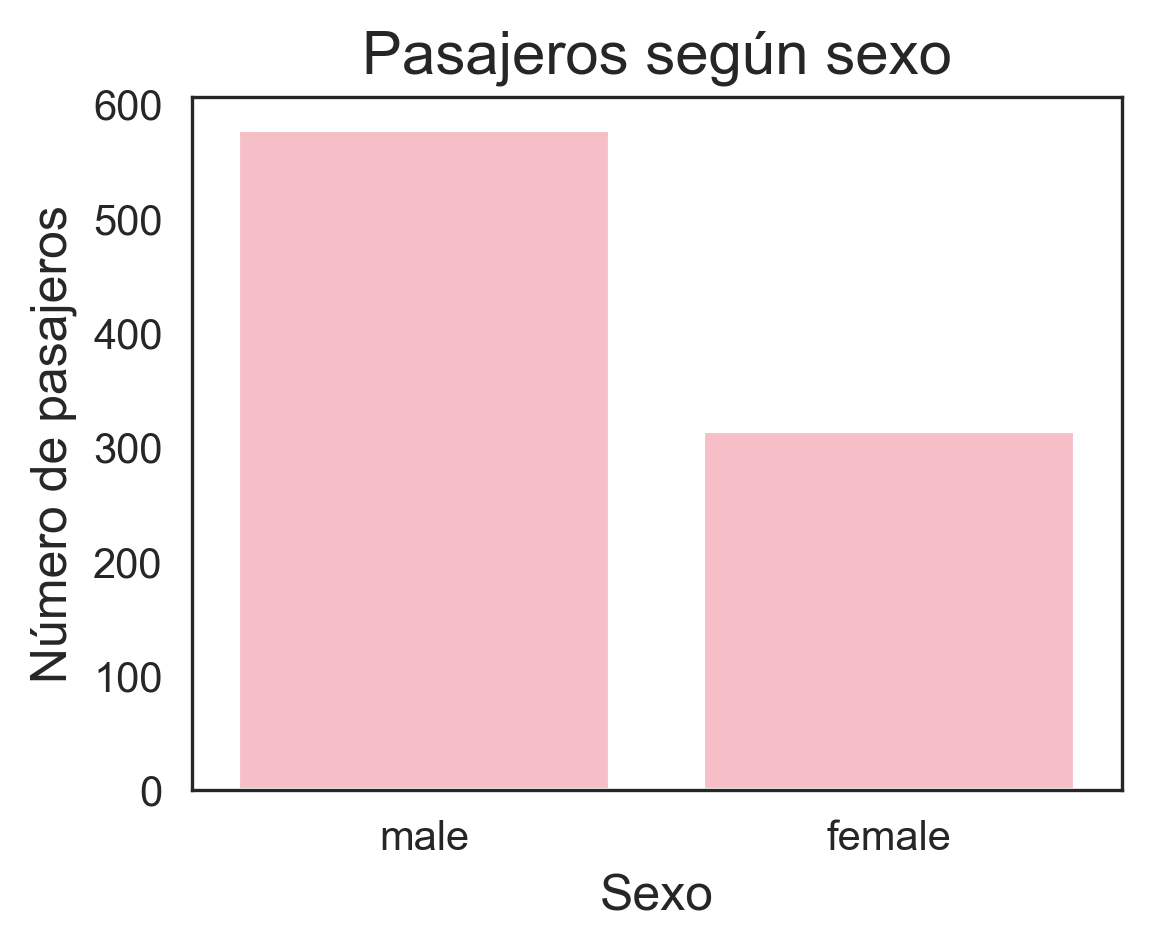

In [255]:
plt.figure(figsize=(4,3))
sns.countplot(data=titanic, x="Sex", color="lightpink")
plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según sexo")
plt.show()

### Ahora usted

**1. Grafique la cantidad de pasajeros según `Pclass`.**

- Qué clase contiene más pasajeros? La clase que contiene más pasajeros es la tercera clase.
- La muestra está balanceada entre las tres clases? No se muestra bien balanceada, puesto que hay una menos cantidad de pasajeros en la clase 2, luego un poco más en la clase 1 y mucho más en clase 3.


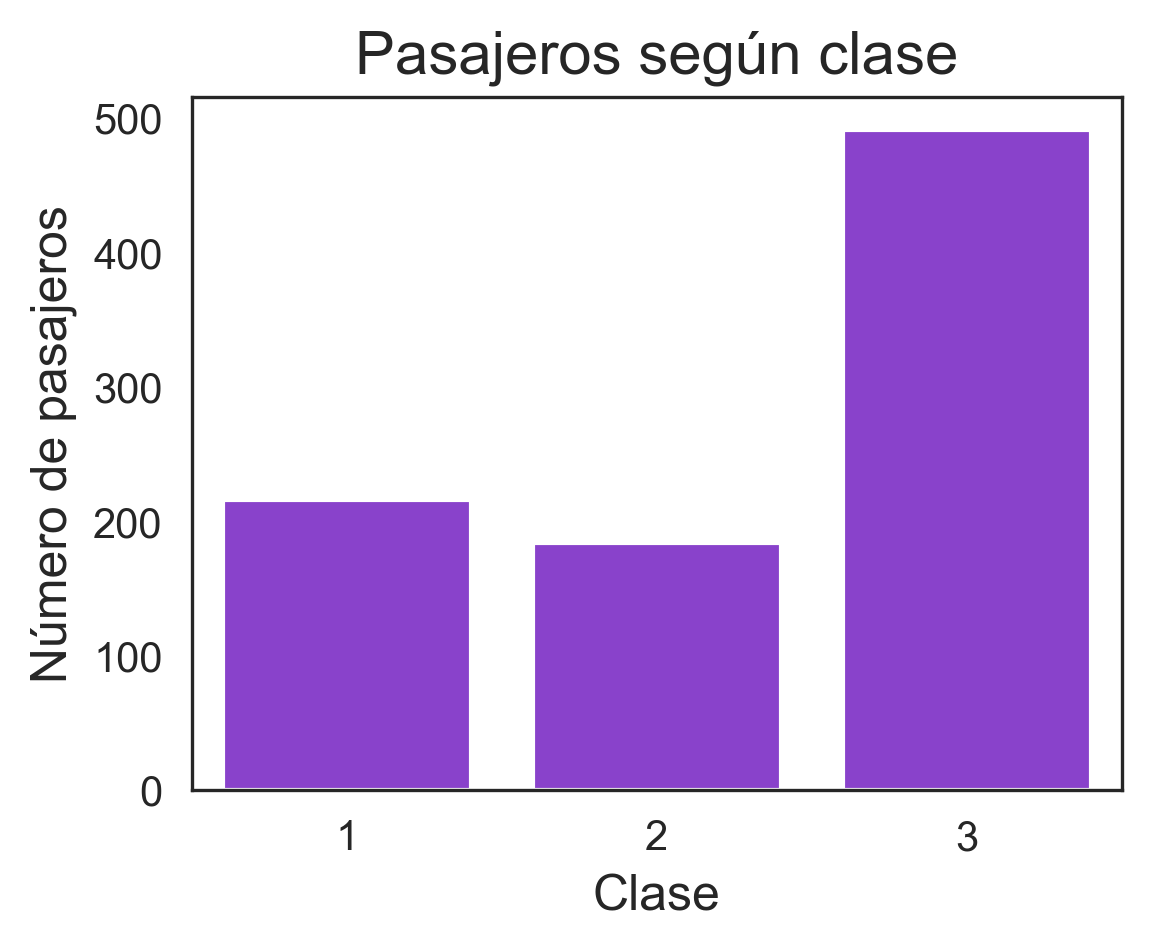

In [256]:
# Escriba aquí su código
plt.figure(figsize=(4,3))
sns.countplot(data=titanic, x="Pclass", color="blueviolet")
plt.xlabel("Clase")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según clase")
plt.show()

**2. Explore la distribución de `Age` con un histograma.**

Pruebe, por ejemplo, con 15, 30 y 50 bins.

- ¿Qué edades son más frecuentes?

    - Utilizando 15 bins las edades más frecuentes notan entre 20 y 30 años aproximadamente
    - Utilizando 30 bins las edades menos frecuentes notan entre 20 y 35 años muy aproximadamente
    - Utilizando 50 bins la visualización se concentra más hacia 20-21 años, pero con unos rangos entremedio como desde 20 a 28 años.
      
- ¿La distribución parece simétrica? Yo diría que sí, porque se notan unos peaks pero tanto hacia los "wings" o a las alas tanto para el lado izquierdo y derecho la distribución decae algo regular.
- ¿El número de bins cambia su interpretación? Puede ser, porque uno puede notar un peak por ejemplo para 15 bins, en aprox 28-30 años pero en 50 bins por ejemplo hay un peak más prominente para aprox 18-21 años viendolo muy estimadamente.


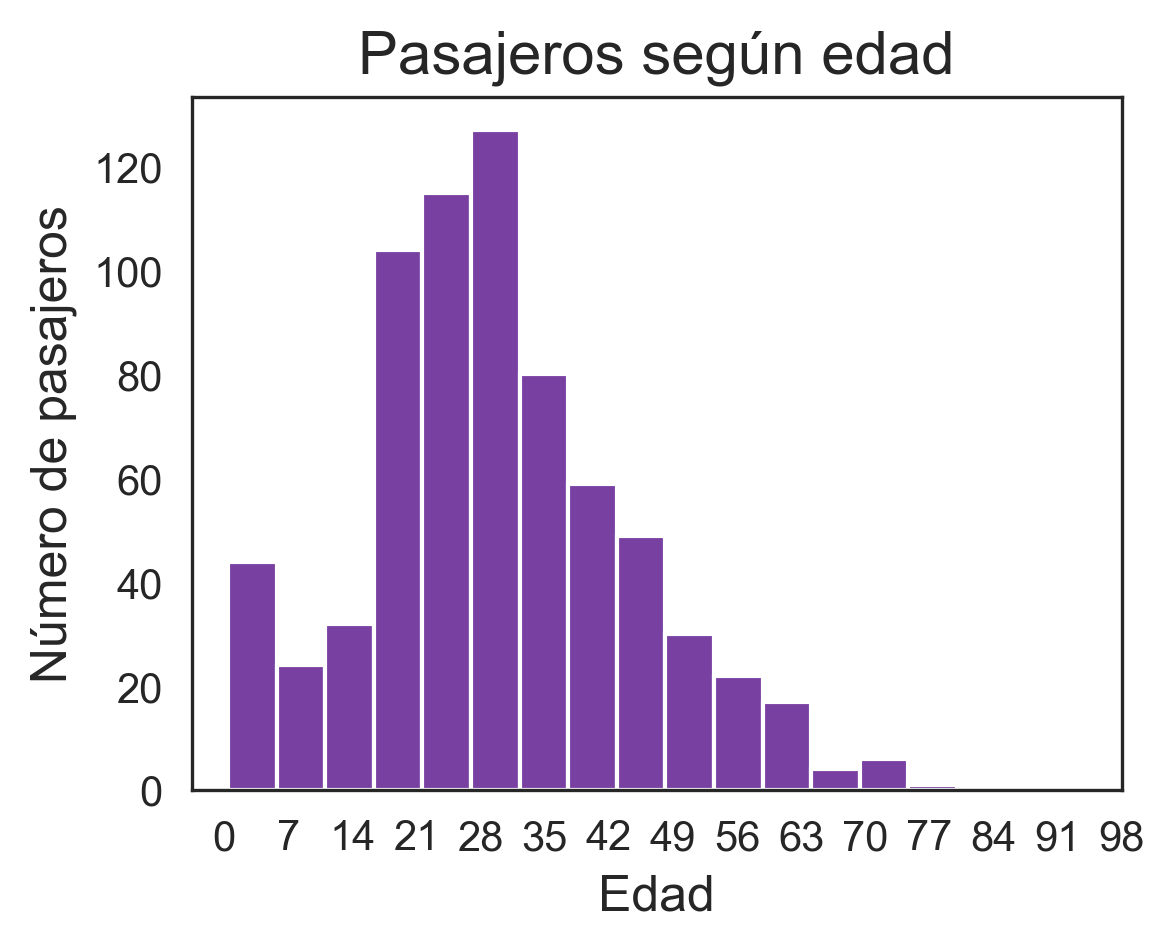

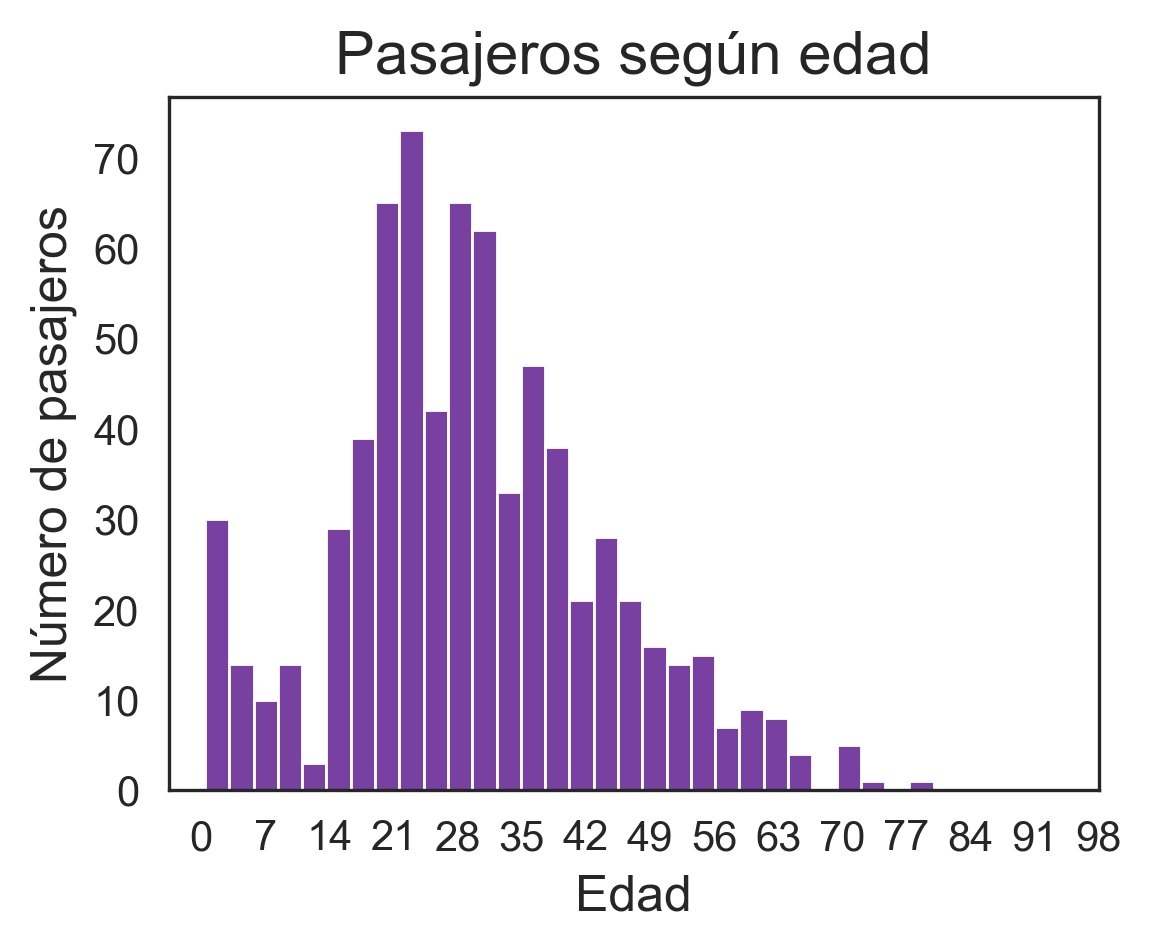

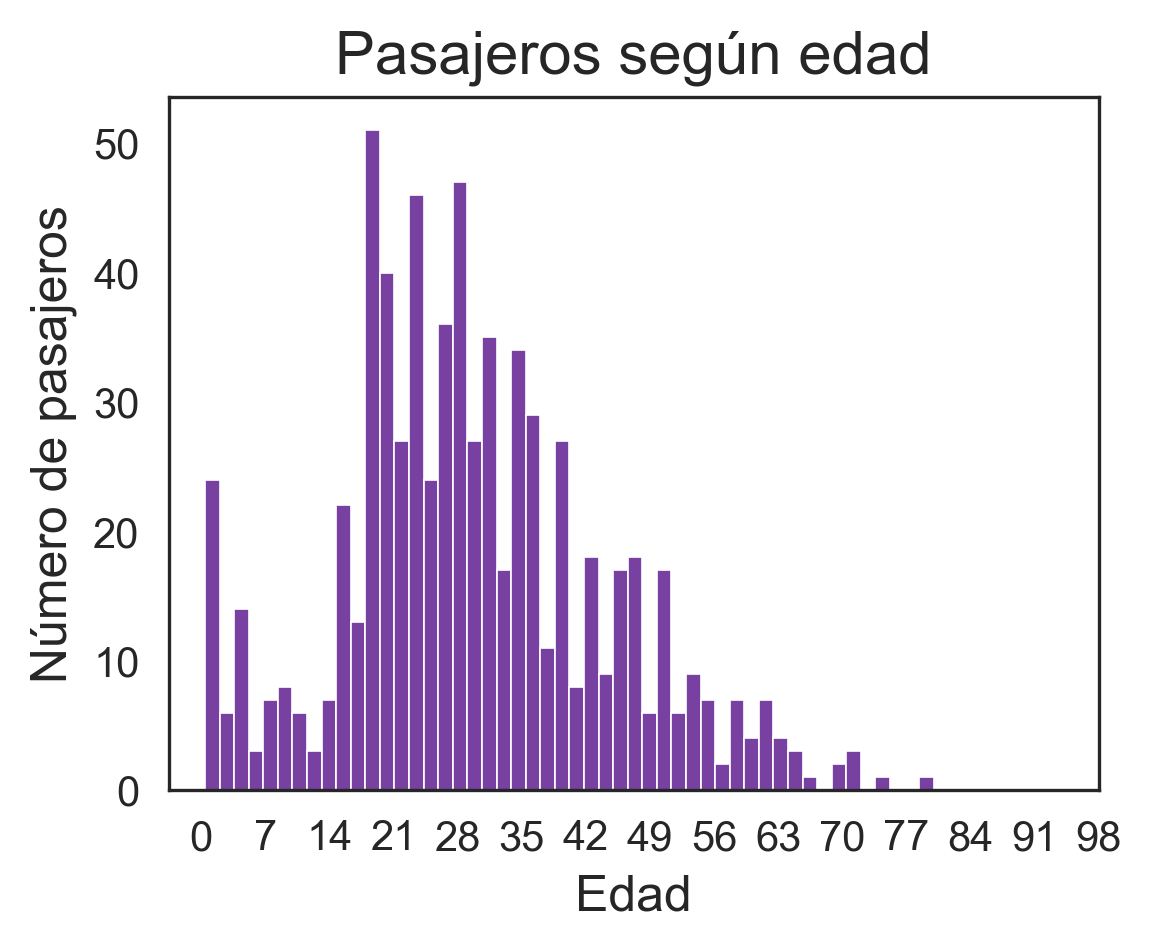

In [257]:
# Escriba aquí su código
bins=[15,30,50]

for binnie in bins:
    binn = binnie
    plt.figure(figsize=(4,3))
    sns.histplot(data=titanic, x="Age", color="indigo", bins=binn)
    plt.xlabel("Edad")
    plt.ylabel("Número de pasajeros")
    plt.title("Pasajeros según edad")
    plt.xticks(range(0, 100, 7)) 
    plt.show()

**3. Explore la distribución de `Fare`.**

Puede usar un histograma o un boxplot.

- ¿La distribución es simétrica? No es simétrica, se puede notar que muchos pasajeros compran tickets a relativos bajos precios.
- ¿Existen tarifas muy superiores al resto? Si existen, pero muy pocas.
- ¿Qué podría significar esto? Que probablemente hay personas con más dinero que costean tickets a más alto precio, pero puede suceder también (como le pasó a Jack) que alguien ganó un ticket, pudo haber existido la posibilidad de la ganancia en cualquier clase creo yo. 


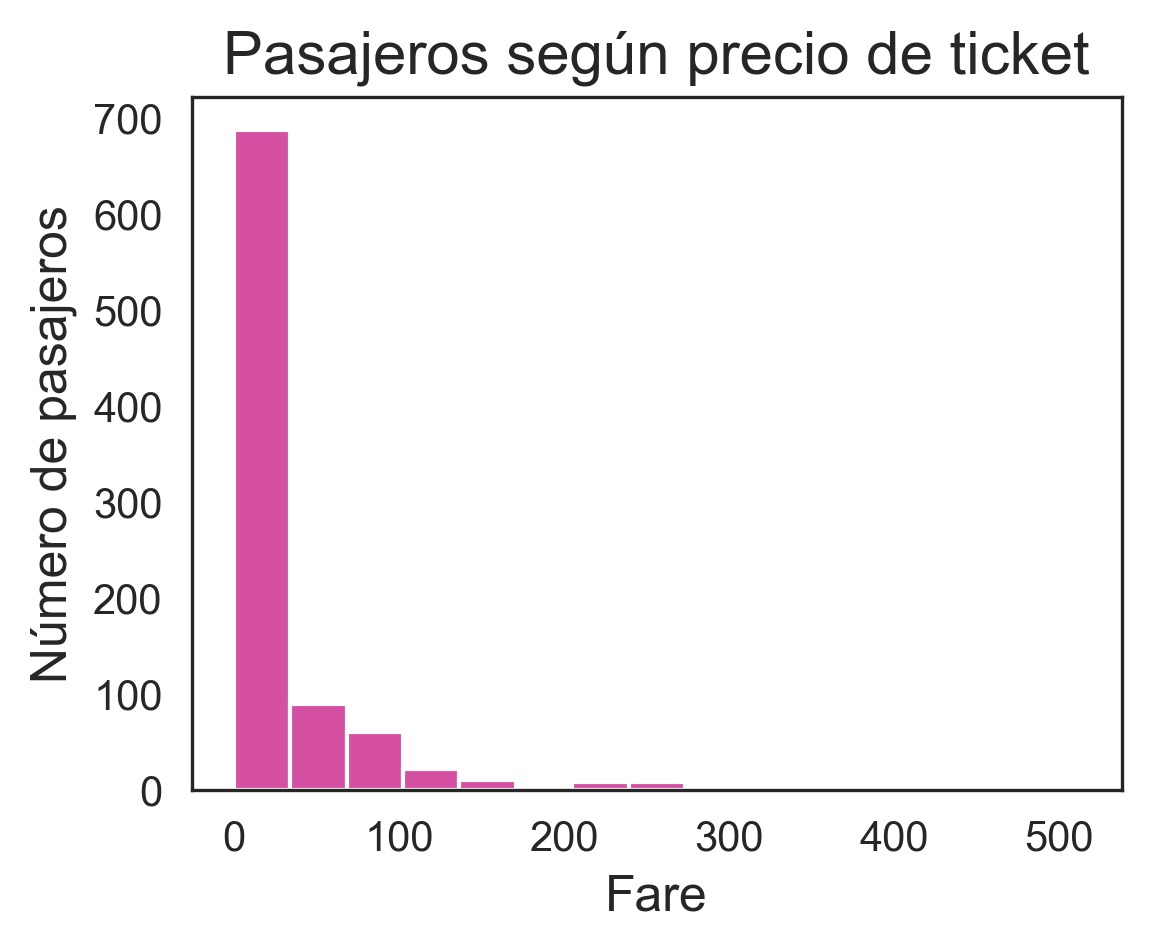

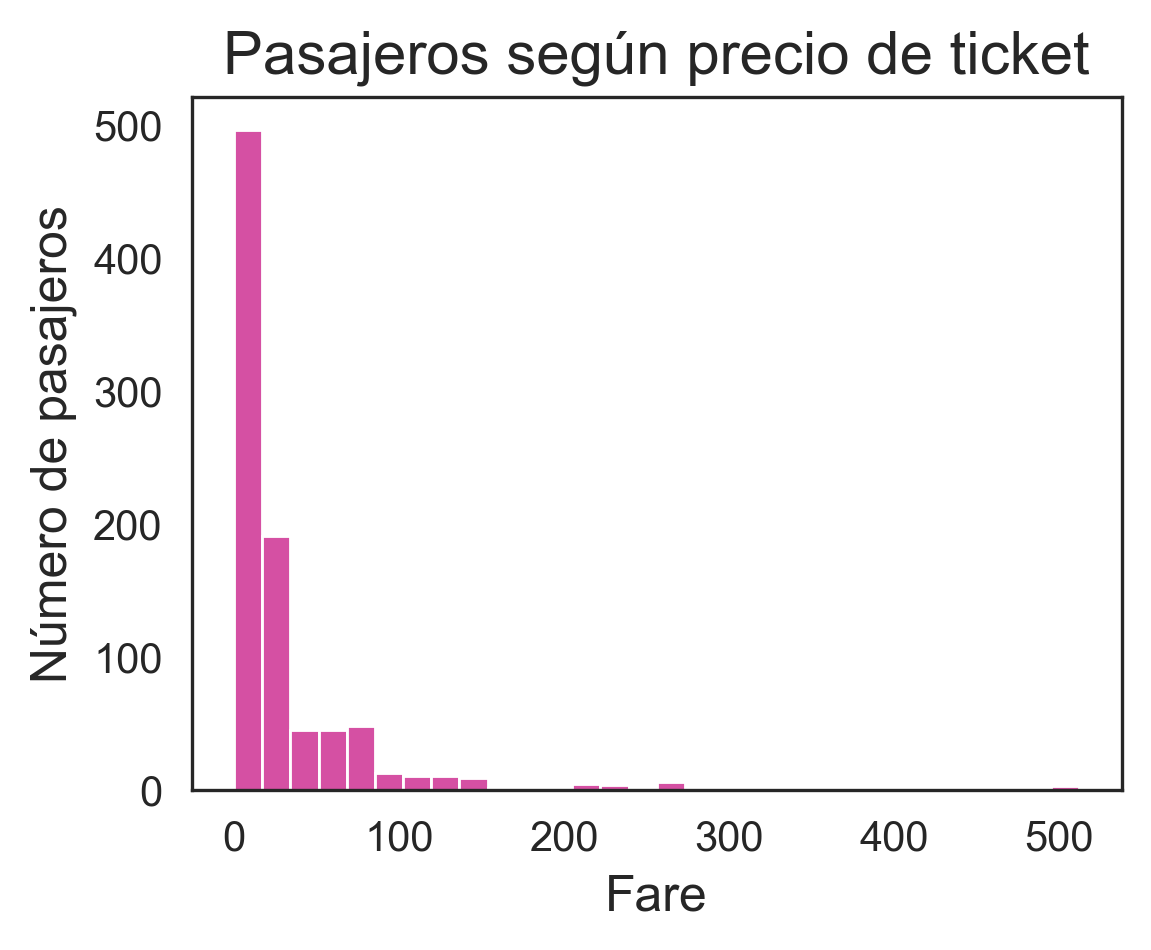

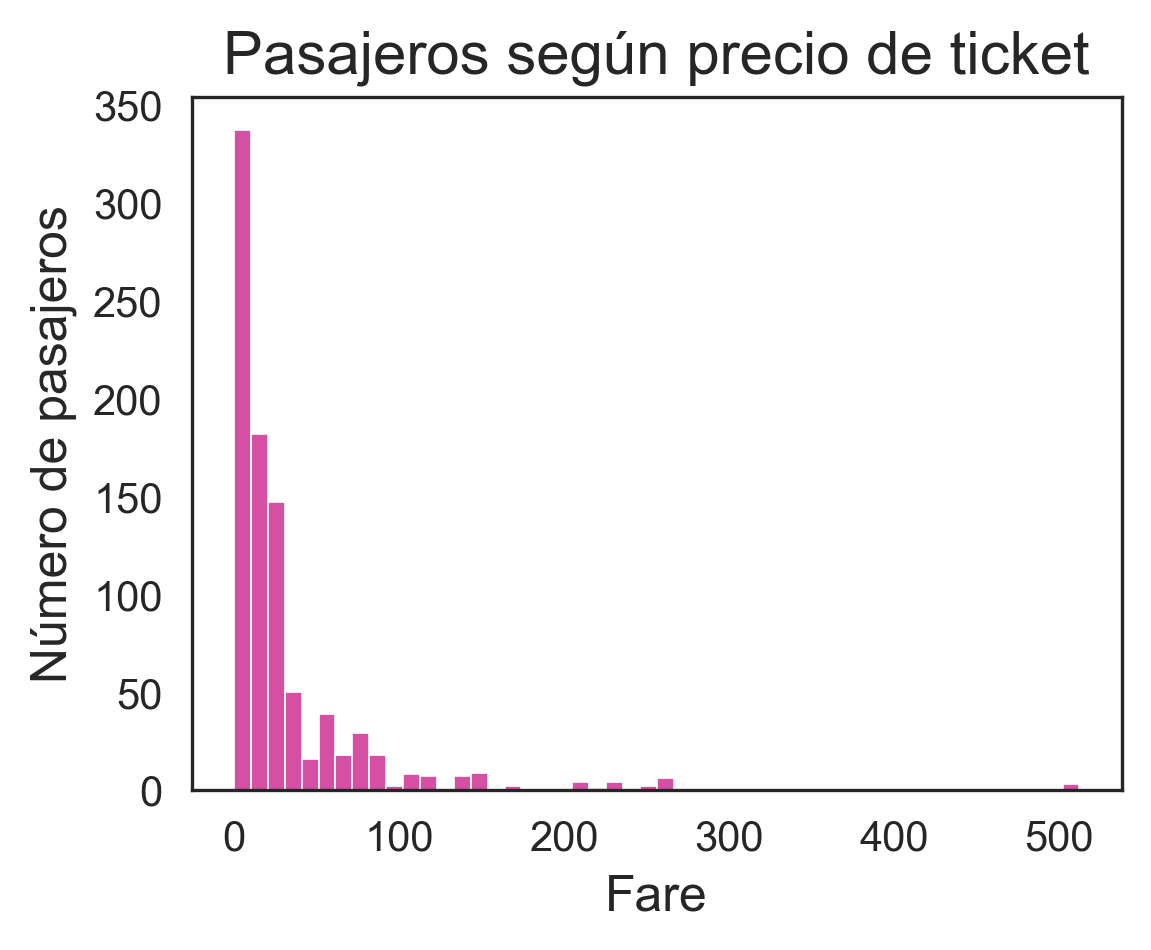

In [258]:
# Escriba aquí su código
bins=[15,30,50]
for binnie in bins:
    binn = binnie
    plt.figure(figsize=(4,3))
    sns.histplot(data=titanic, x="Fare", color="mediumvioletred",bins=binn)
    plt.xlabel("Fare")
    plt.ylabel("Número de pasajeros")
    plt.title("Pasajeros según precio de ticket")
    plt.show()

# Parte 2: Calidad de los datos

## ¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes, puesto que como se había visto antes pueden haber pasajeros con categorías consideradas como NaN.
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


In [259]:
datos_faltantes = titanic.isnull().sum() #valores que faltan en la tabla
datos_faltantes

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica.


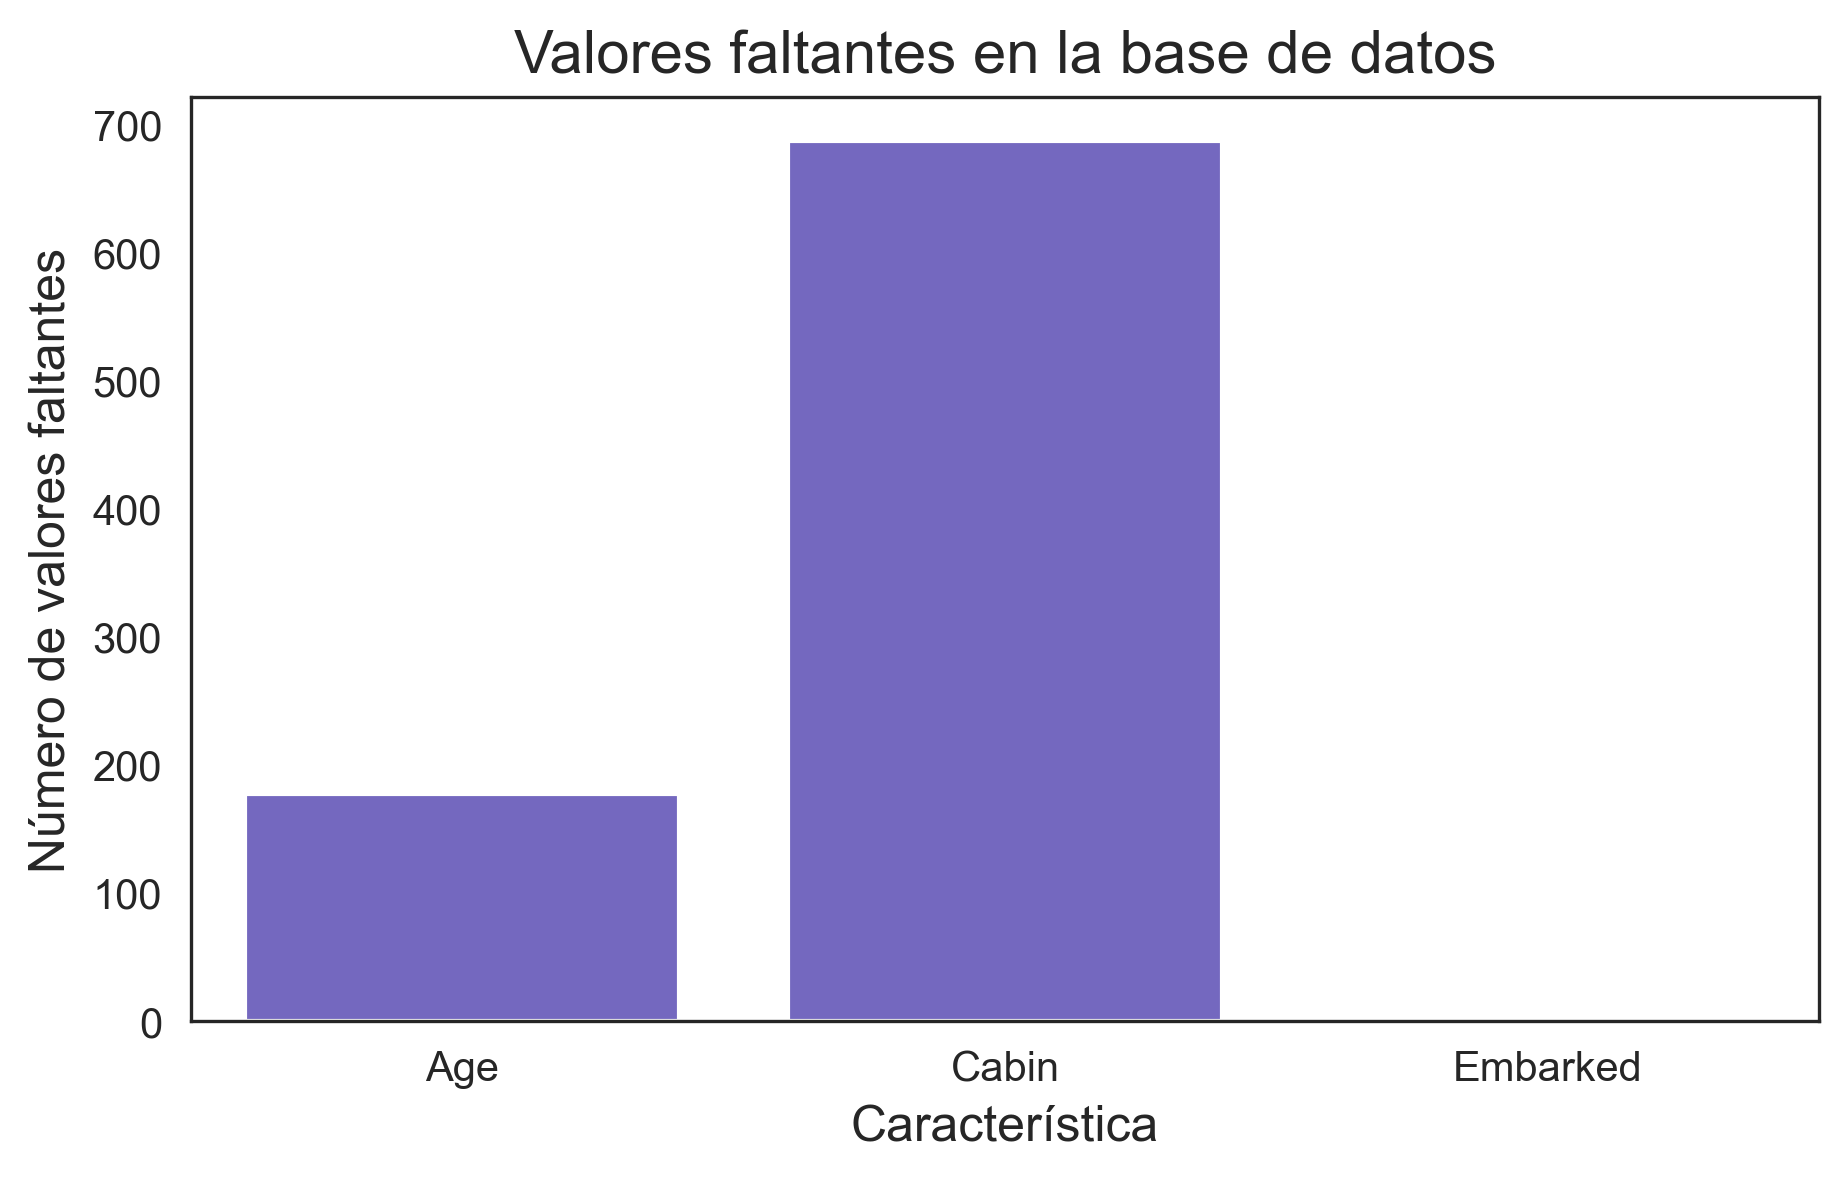

In [260]:
faltantes = datos_faltantes[datos_faltantes > 0]
plt.figure(figsize=(7,4))
sns.barplot(x=faltantes.index, y=faltantes.values, color='slateblue')
plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.title("Valores faltantes en la base de datos")
plt.show()

### Ahora usted

Observe especialmente `Age`, `Cabin` y `Embarked`.

**1. Compare la media y la mediana de `Age`.**
Para la mediana de la edad se obtuvo 28.0 años y para la media se obtuvo aproximadamente 29.7 años.

- Son similares? Relativamente sí.
- Es la media una buena representación de una edad típica? Yo diría que más o menos, dado que la media tiende a ser más sensible a los datos, en cambio la mediana no.


In [261]:
# Escriba aquí su código
#media y mediana de age
age = int(datos_faltantes[datos_faltantes > 0]["Age"])
cab = int(datos_faltantes[datos_faltantes > 0]["Cabin"])
emb = int(datos_faltantes[datos_faltantes > 0]["Embarked"])
#Mediana y media de age
print(np.median((titanic["Age"]).dropna()),np.mean((titanic["Age"]).dropna()))
age,cab,emb

28.0 29.69911764705882


(177, 687, 2)

<h2 style="color:Fuchsia; font-family: Arial; text-align:center;font-size:18px">
  Boxplots para edades
</h2>

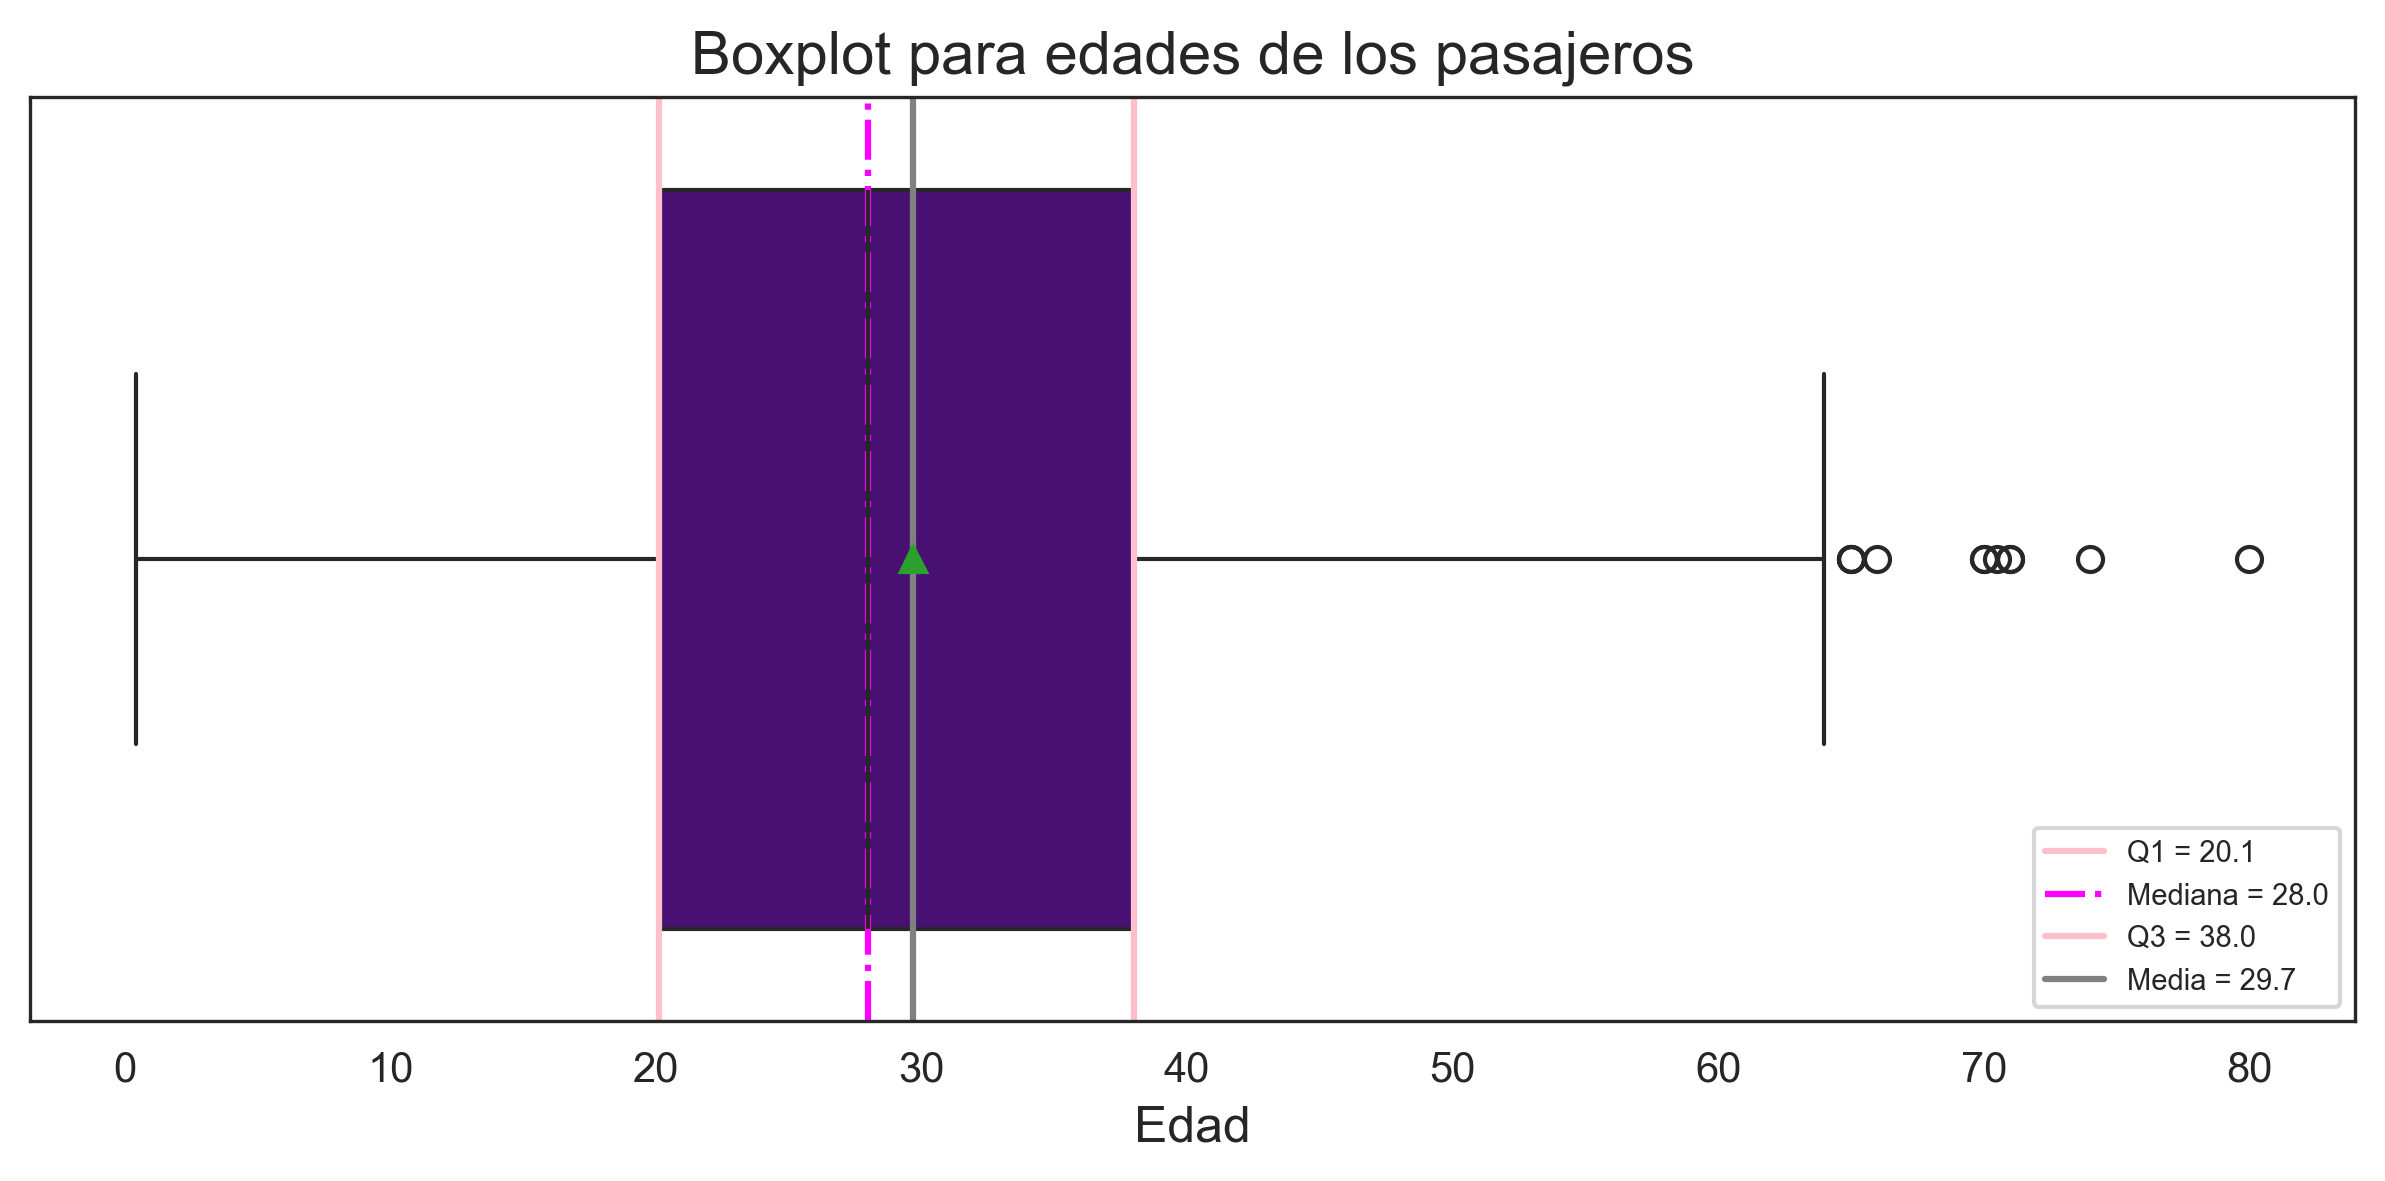

29.69911764705882 28.0 20.125 38.0


In [262]:
titanic = pd.read_csv("titanic_semana_02.csv")
plt.figure(figsize=(10, 4))
sns.boxplot(data=titanic, x="Age", color="indigo", showmeans=True)
#Para localizar cuartiles, media y mediana
median = titanic["Age"].median()
mean = titanic["Age"].mean()
Q1 = titanic["Age"].quantile(0.25)
Q3 = titanic["Age"].quantile(0.75)
mean = titanic["Age"].mean()
plt.axvline(Q1, color="pink", linestyle="-", label=f"Q1 = {q1:.1f}")
plt.axvline(median, color="fuchsia", linestyle="-.", label=f"Mediana = {mediana:.1f}")
plt.axvline(Q3, color="pink", linestyle="-", label=f"Q3 = {q3:.1f}")
plt.axvline(mean, color="grey", linestyle="-", label=f"Media = {media:.1f}")
plt.xlabel("Edad")
plt.title("Boxplot para edades de los pasajeros")
plt.legend(fontsize=7,loc="lower right")
plt.show()
print(mean, median,Q1,Q3)

**2. La edad tiene datos faltantes.**

- Le parece razonable reemplazar todas las edades faltantes por la media? Puede ser, puesto que los datos faltantes serían casi 20% del total de datos, entonces podría considerarse relativamente una cantidad algo menor (aunque igual considerable)como datos faltantes para la edad respecto al total para los pasajeros (891).
- Qué problema podría producir esa decisión en la distribución de edades? Como se puede ver en el boxplot de arriba la mediana está trasladada un poco hacia la izquierda en comparación con la media. En cambio para el boxplot que considera los valores faltantes de edades como la media, tanto la mediana como la media quedan localizadas en un mismo lugar. La distribución como tal, al agregar la media a valores faltantes hace que desde un rango aproximado 20.125 a 38 de edad pase a aproximadamente 22 a 35 años (observando [Q1,Q3], y para este último aparecen outliers de la muestra, considerados como valores extremos (se pueden ver como circulitos sin rellenar). Claramente se los datos se concentraran en el mismo valor de la media, resultando en que como se ha agregado "artificialmente" la distribución no sería representativa.
- Qué otra estrategia consideraría? La otra opción sería reemplazar la mediana, puesto que es menos sensible a valores extremos y mejor para la distribución al momento que presente una leve asimetría positiva en boxplot (hacia la izquierda).


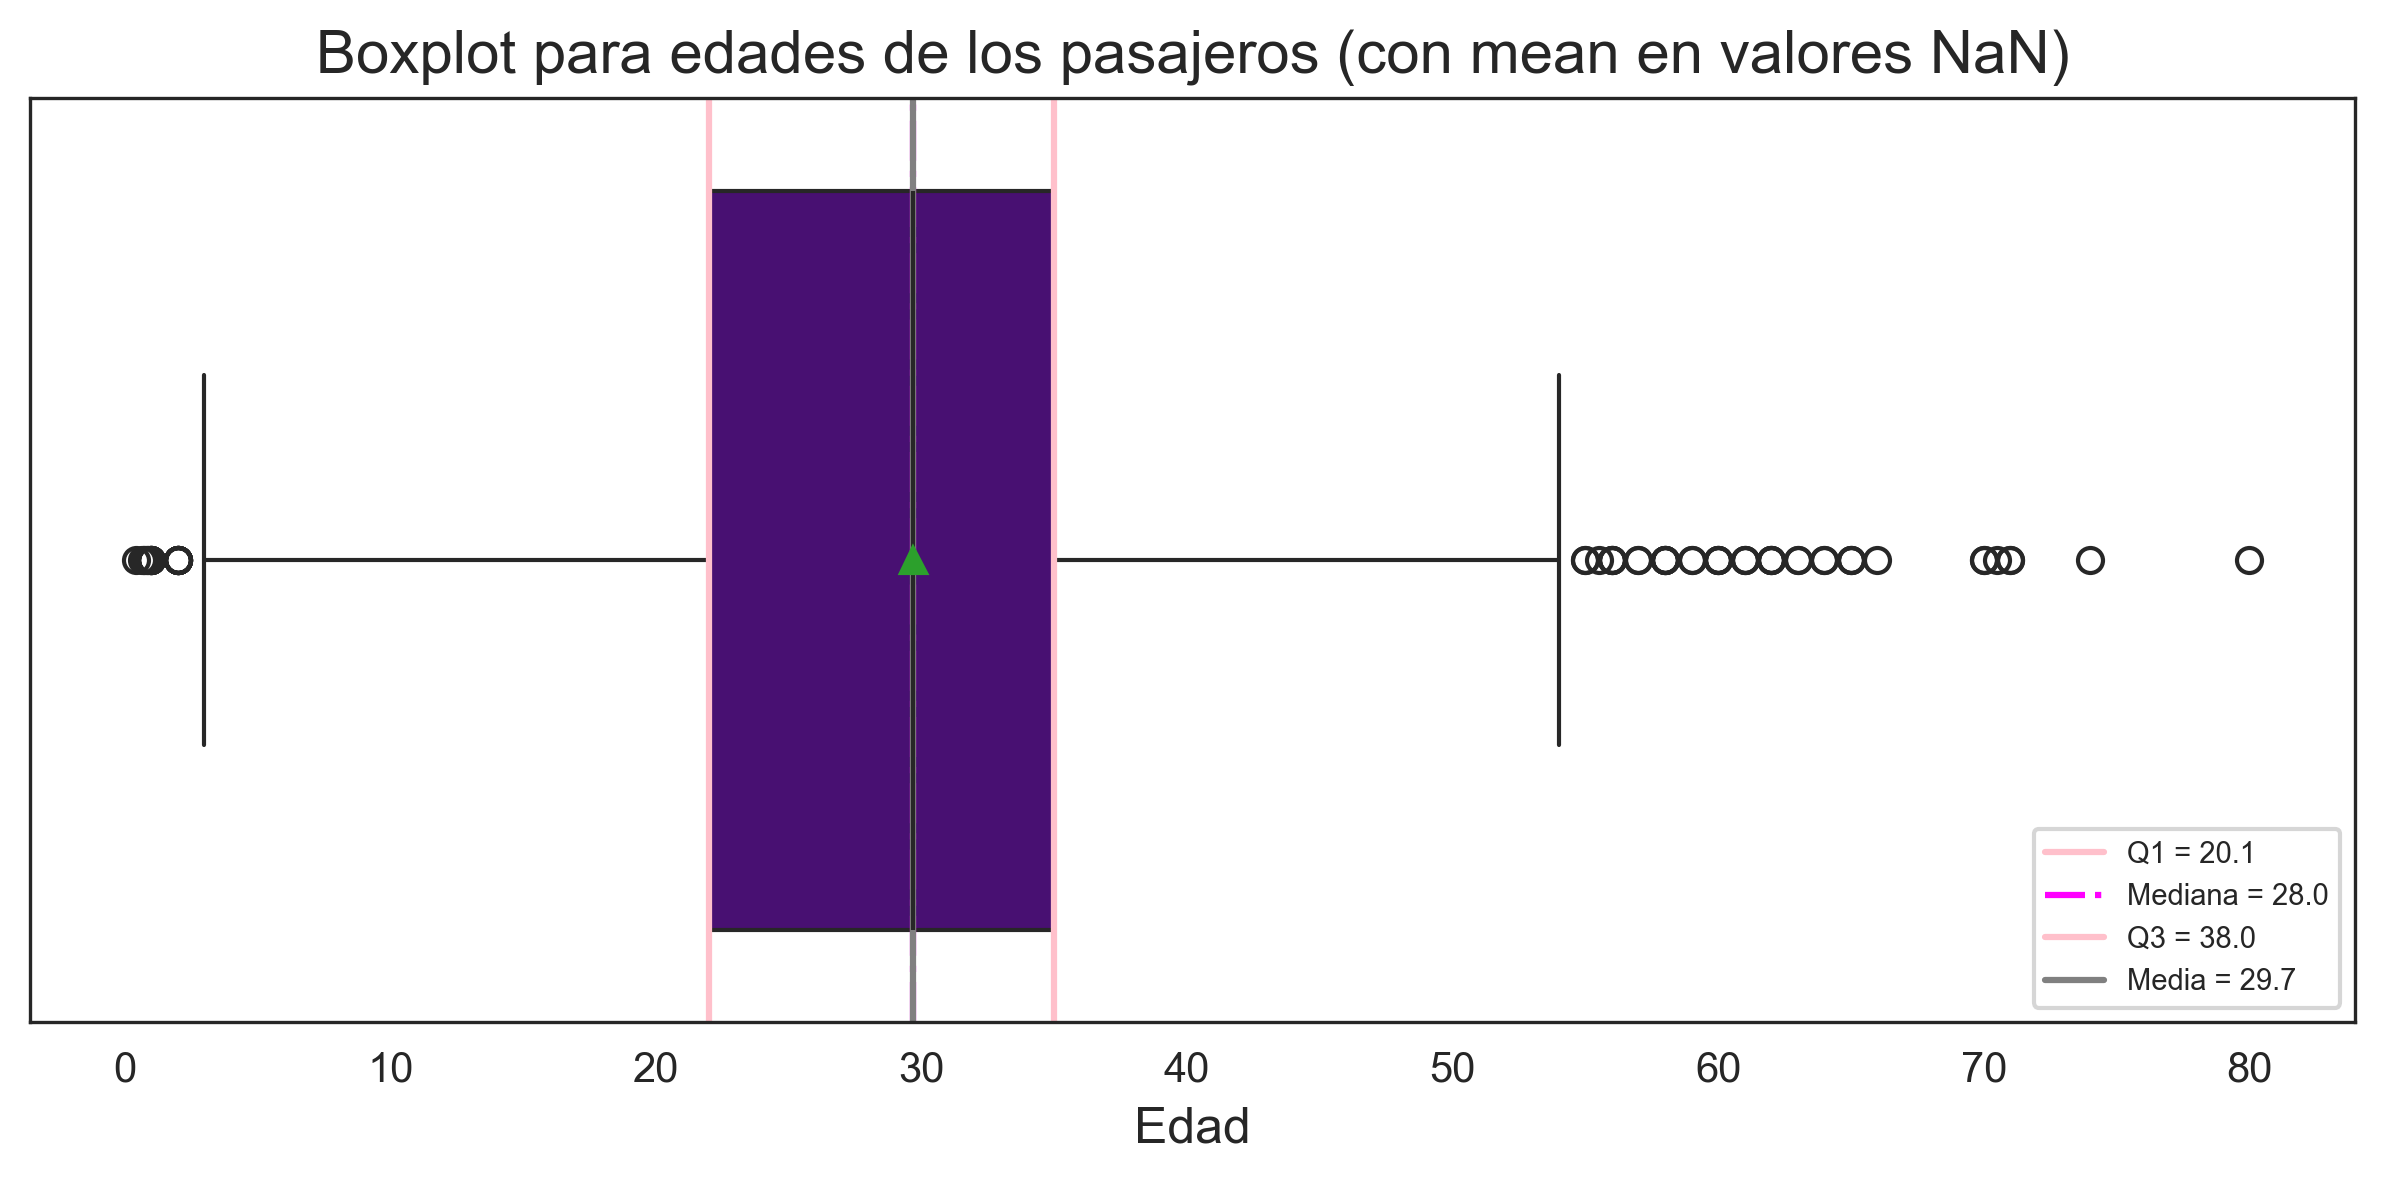

29.69911764705882 29.69911764705882 22.0 35.0


In [263]:
#Aquí escribo de nuevo la tabla del titanic pero con nombre titanic2 para no confundir, para la tabla con datos rellenos para la edad
titanic2 = pd.read_csv("titanic_semana_02.csv")
titanic2["Age"] = titanic2["Age"].fillna(mean) #agregando la media a los datos faltantes para la edad
plt.figure(figsize=(10, 4))
sns.boxplot(data=titanic2, x="Age", color="indigo", showmeans=True)
#Para localizar cuartiles, media y mediana
median = titanic2["Age"].median()
mean = titanic2["Age"].mean()
Q1 = titanic2["Age"].quantile(0.25)
Q3 = titanic2["Age"].quantile(0.75)
mean = titanic2["Age"].mean()
plt.axvline(Q1, color="pink", linestyle="-", label=f"Q1 = {q1:.1f}")
plt.axvline(median, color="fuchsia", linestyle="-.", label=f"Mediana = {mediana:.1f}")
plt.axvline(Q3, color="pink", linestyle="-", label=f"Q3 = {q3:.1f}")
plt.axvline(mean, color="grey", linestyle="-", label=f"Media = {media:.1f}")
plt.xlabel("Edad")
plt.title("Boxplot para edades de los pasajeros (con mean en valores NaN)")
plt.legend(fontsize=7,loc="lower right")
plt.show()
print(mean, median,Q1,Q3)

**3. `Cabin` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos? No, dado que aparte que son muchos los datos faltantes. Si se rellenarán la distribución sería menos representativa-
- Eliminaría la característica? Quizás si es que no afectan mucho a la muestra en total, pero de igual forma podría determinar algún factor de interés como por ejemplo si es que la/s persona/s sobrevivió o no puesto que localiza al pasajero, puede ser de acuerdo a la clase quizás. 
- Podría el hecho de conocer o no la cabina contener información por sí mismo? Quizás podría contener, porque como se había mencionado al conocer la cabina, si una clase específica cuya variable es "Pclass", está en su determinada cabina puede existir el factor decisivo de supervivencia o no.

In [264]:
#Para trabajar con las edades y clases, como se tenían inicialmente datos faltantes en edades, el package de pandas
#ignora los valores nulos cuando se calculan el promedio y mediana, entonces esto es útil para "clasificar" que datos
#van a graficarse para ver la distribución 


<h2 style="color:Fuchsia; font-family: Arial; text-align:center;font-size:18px">
  Histograma para edades
</h2>

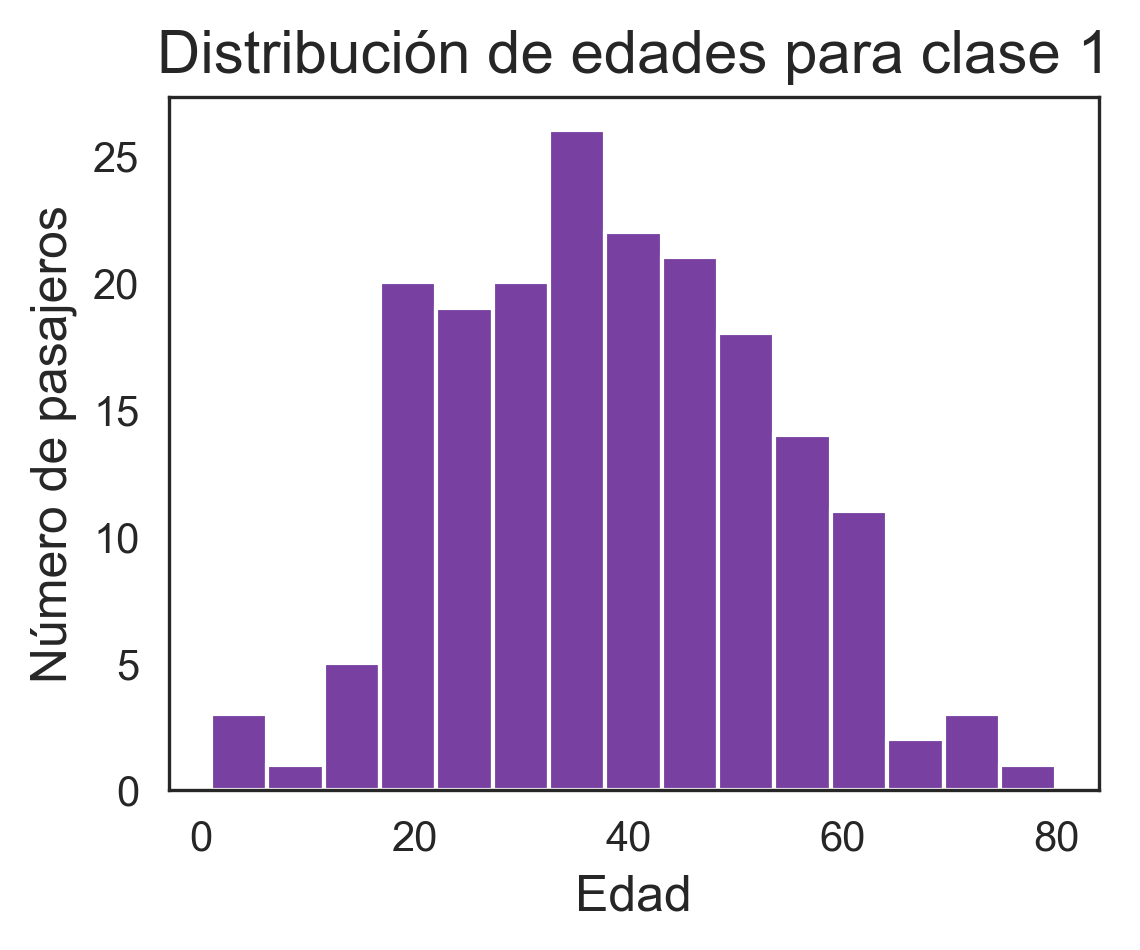

Valor de la mediana para clase 1: 37.00
Valor de la media para clase 1: 38.23


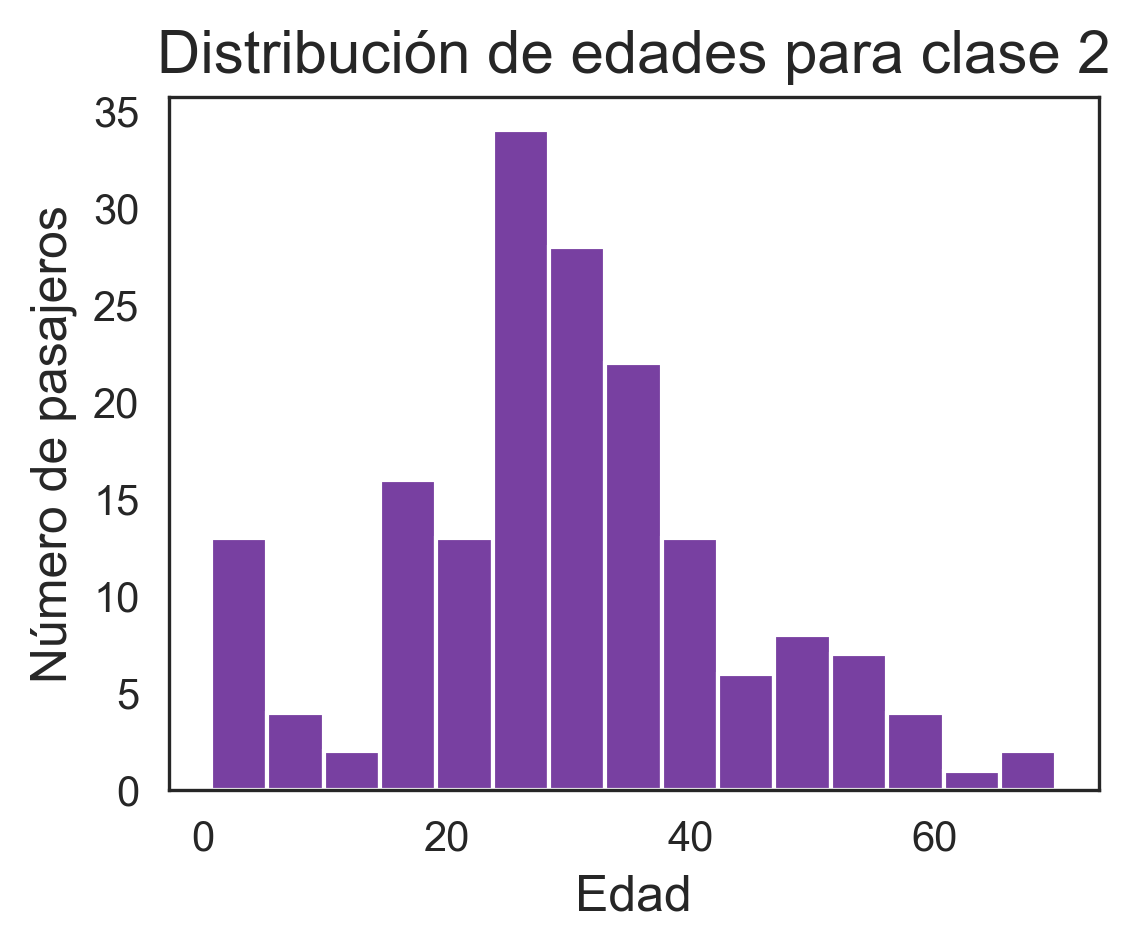

Valor de la mediana para clase 2: 29.00
Valor de la media para clase 2: 29.88


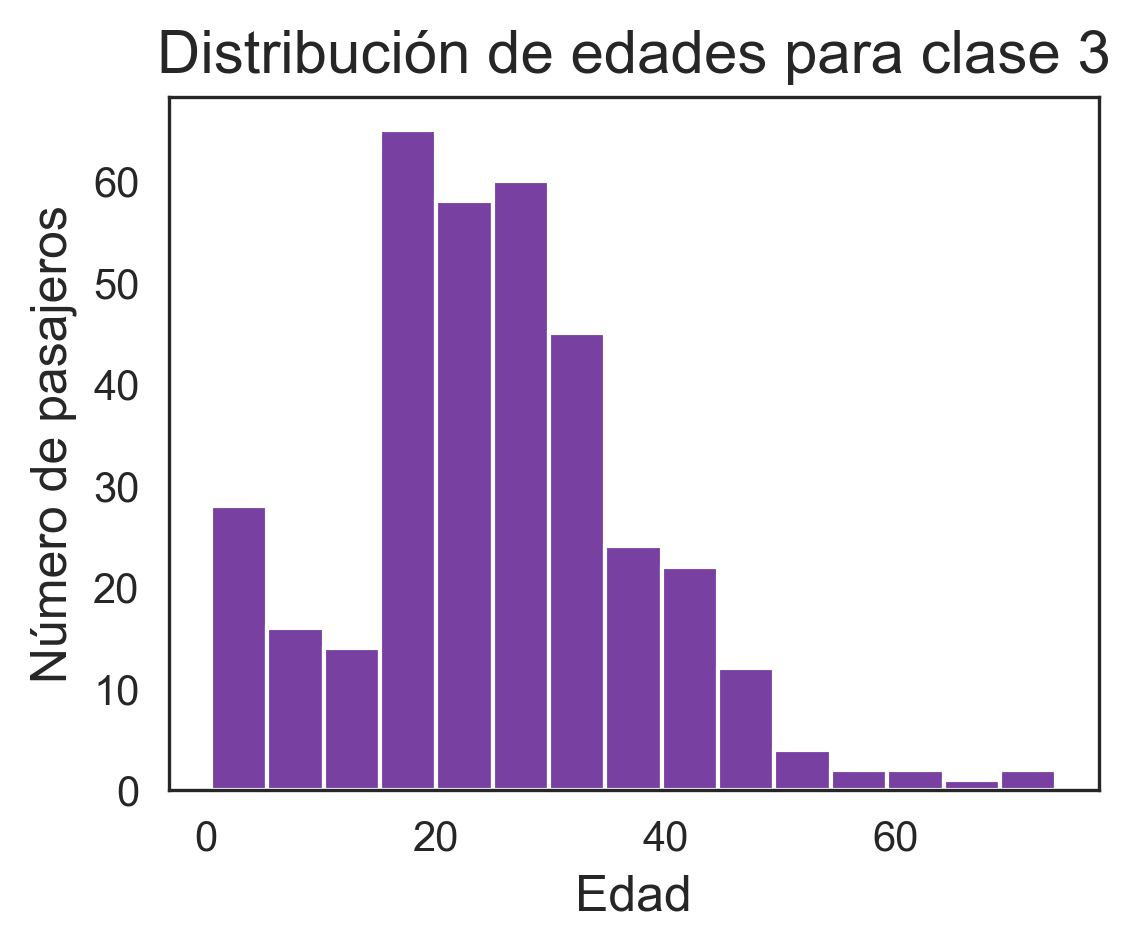

Valor de la mediana para clase 3: 24.00
Valor de la media para clase 3: 25.14


In [265]:
#Ahora considerando los boxplots para cada clase como factor "muestral" además de cabin
#teniendo en cuenta la variable titanic (tabla) donde faltan datos de las edades, puesto que es lo original
#si considero titanic2, la manipulación de datos estaría muy notable en la distribución final.
for clasenum in [1, 2, 3]:
    clasee = titanic[(titanic["Age"].notnull()) & (titanic["Pclass"] == clasenum)]
    plt.figure(figsize=(4,3))
    sns.histplot(data=clasee, x="Age", color="indigo", bins=15)
    plt.xlabel("Edad")
    plt.ylabel("Número de pasajeros")
    plt.title(f"Distribución de edades para clase {clasenum}")
    plt.show()
    print(f"Valor de la mediana para clase {clasenum}: {clasee['Age'].median():.2f}")
    print(f"Valor de la media para clase {clasenum}: {clasee['Age'].mean():.2f}")

Retomando en como se consideran las edades y clase, los valores de edades promedio son 38.23, 29.88, 25.14 años, para clases 1,2 y 3, respectivamente. Y los valores de mediana son 37, 29, 24 años, para clases 1,2 y 3, respectivamente. Claramente, a medida que aumenta la clase aumenta la edad promedio y mediana para los pasajeros. Esto enfatiza de nuevo a que no es recomendable reemplazar el valor de la media en edades faltantes, esta es de 29.69 años, entonces la distribución estaría más concentrada en rangos etarios "jóvenes", lo que no resulta representativo (de nuevo). Además, a partir de los histogramas se ve que desde la clase 1 a la 3 la distribución se va volviendo ligeramente asimétrica. hacia edades un poco más jóvenes.

**4. `Embarked` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso? Yo creo que se podría reemplazar algún que otro parámetro, pero si quizás considerara la media o mediana no existirían quizás cambios considerables como para ver una variación de la distribución a partir de la que se pueda concluir. Luego como se tienen los clasificables para los embarques podría usarse el valor que más se repita dependiendo del embarque, esto es la moda, para enfatizar la categoría. Además, de que no debería afectar tanto la distribución como tal, por ser apenas 0.22% de la cantidad total.
- Por qué el tratamiento puede ser distinto al de `Cabin`? Porque en Cabin al faltar muchos datos, realmente afectaría al reemplazar muchos datos iguales, sería casi todo "inventado", y no resultaría representativo.


# Parte 3: Explorar relaciones entre características

## ¿Cómo se relacionan las características de los pasajeros?

Después de estudiar las características individualmente, podemos comenzar a buscar estructura en los datos.

Preguntas posibles:

- La tarifa pagada está relacionada con la clase? Esto se obtiene desde Fare en conjunto a Pclass
- Las edades son similares en todas las clases? Esto se averigua 
- Quiénes viajaban acompañados? Esto también se investiga
- Hay características que contienen información parcialmente similar? También se indaga en esto

### Ejemplo de gráfico: tarifa según clase

Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.


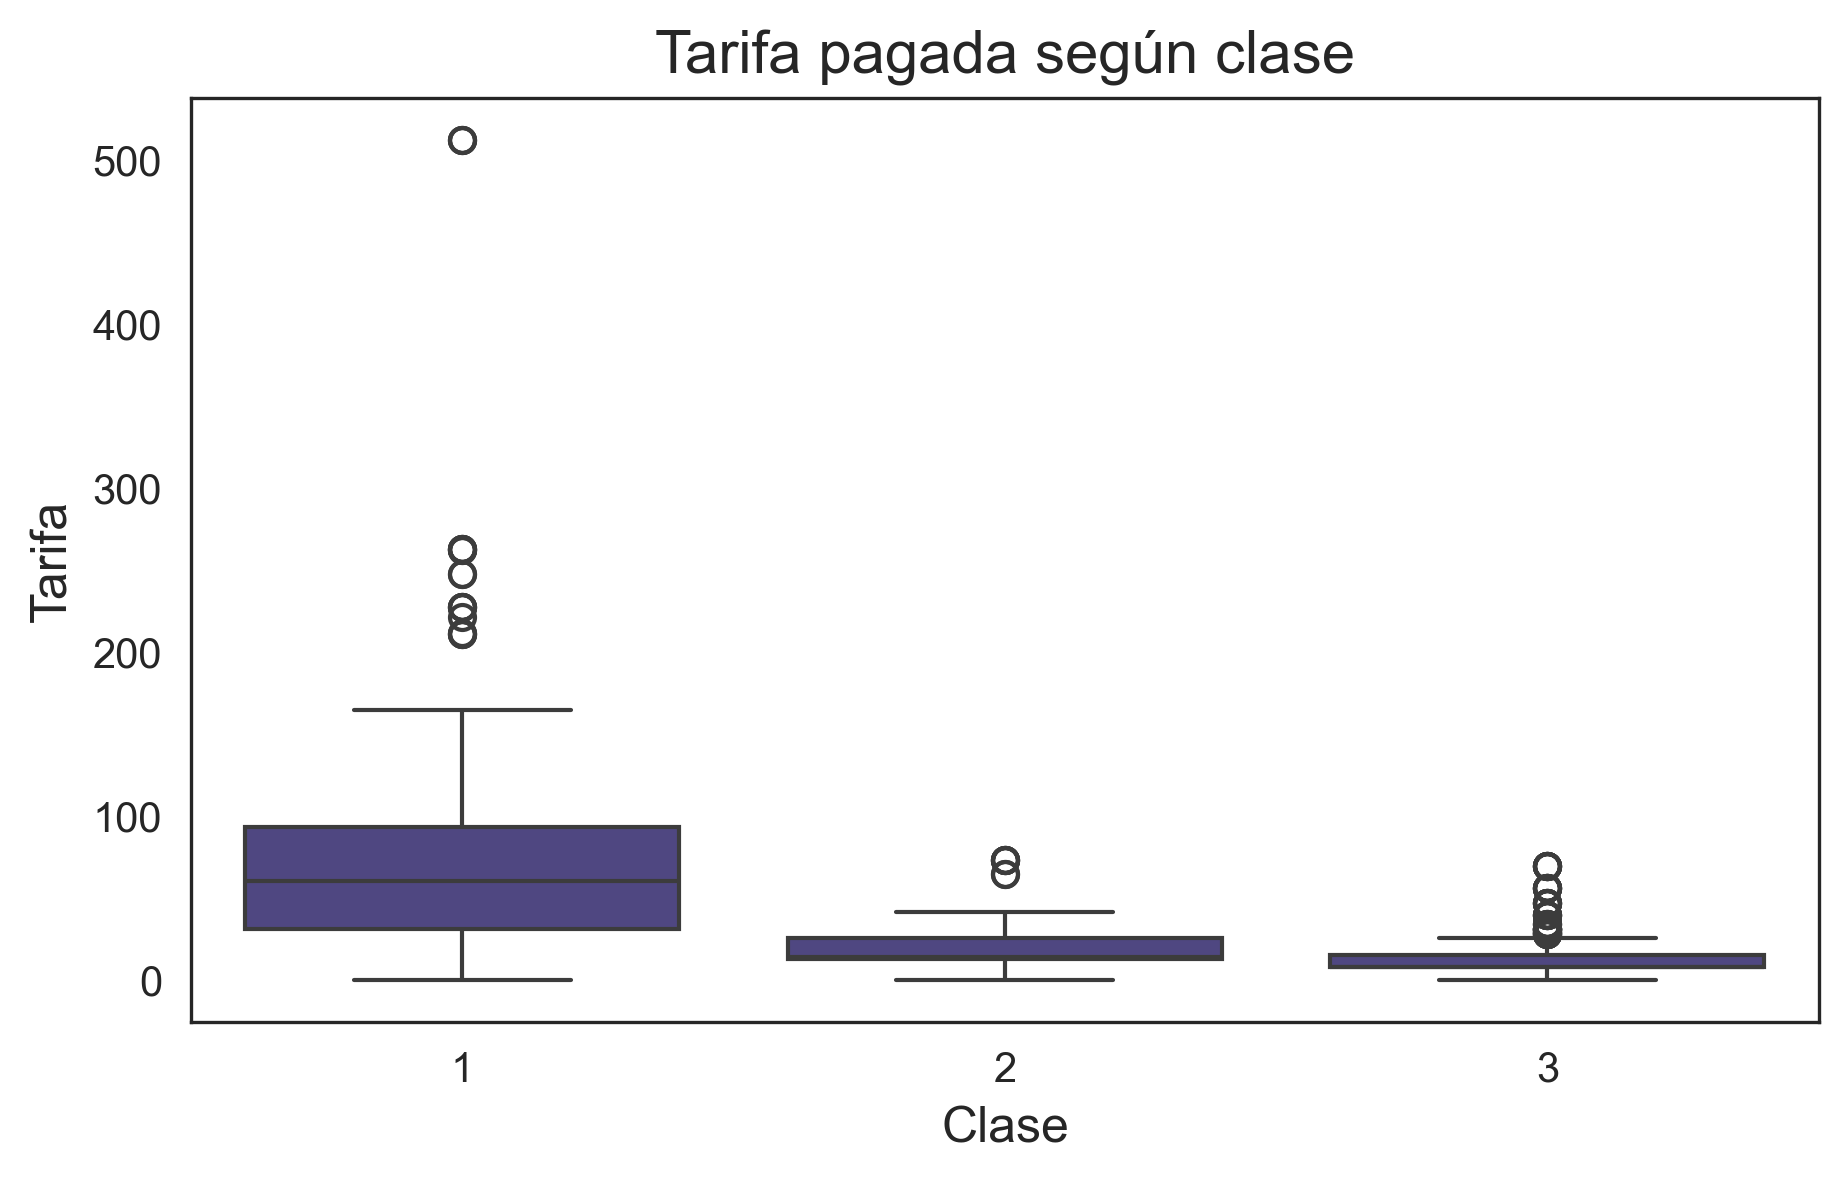

In [266]:
#Figura en general
plt.figure(figsize=(7,4))
sns.boxplot(data=titanic, x="Pclass", y="Fare", color='darkslateblue')
plt.xlabel("Clase")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")
plt.show()

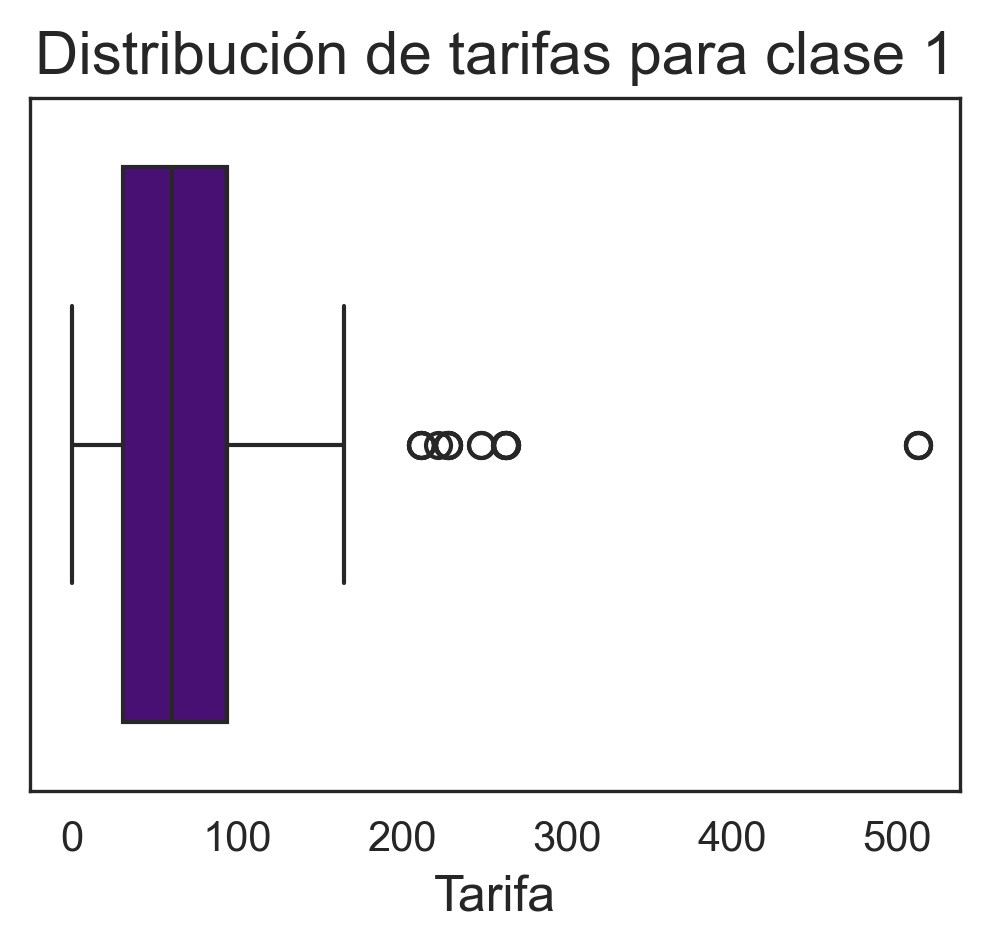

Valor de la mediana para clase 1: 60.29
Valor de la media para clase 1: 84.15


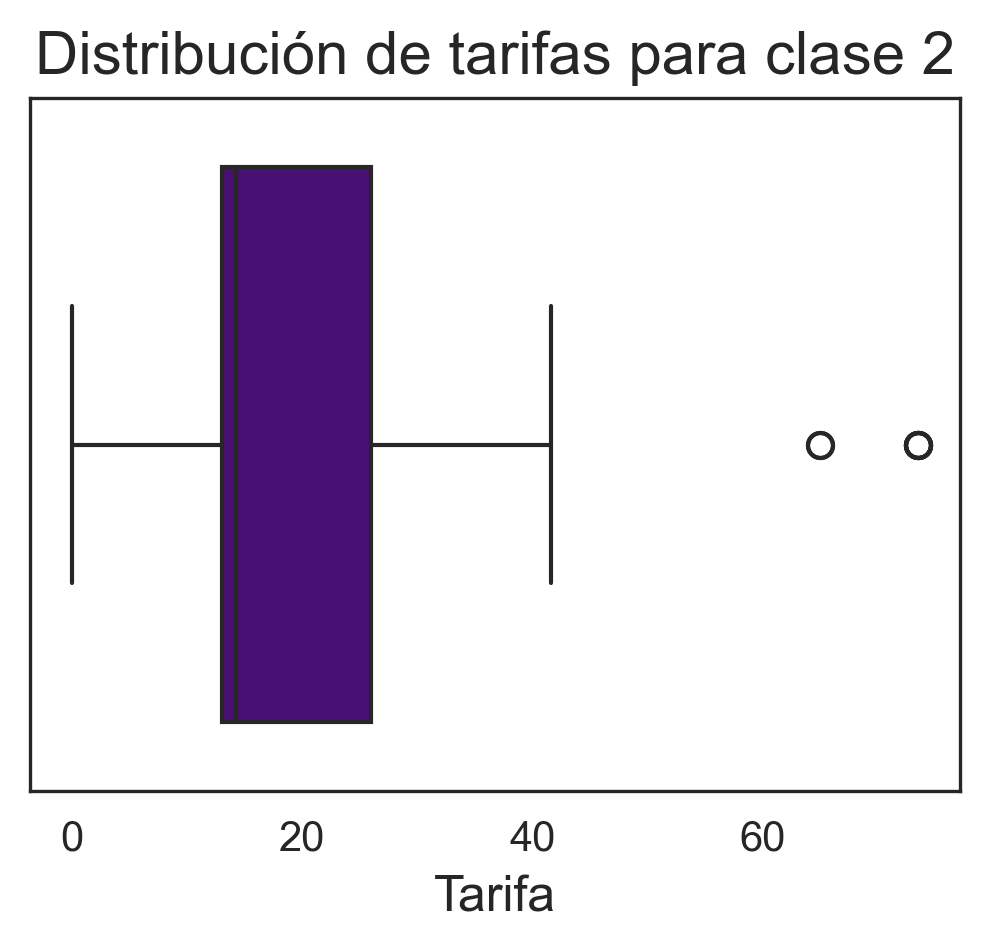

Valor de la mediana para clase 2: 14.25
Valor de la media para clase 2: 20.66


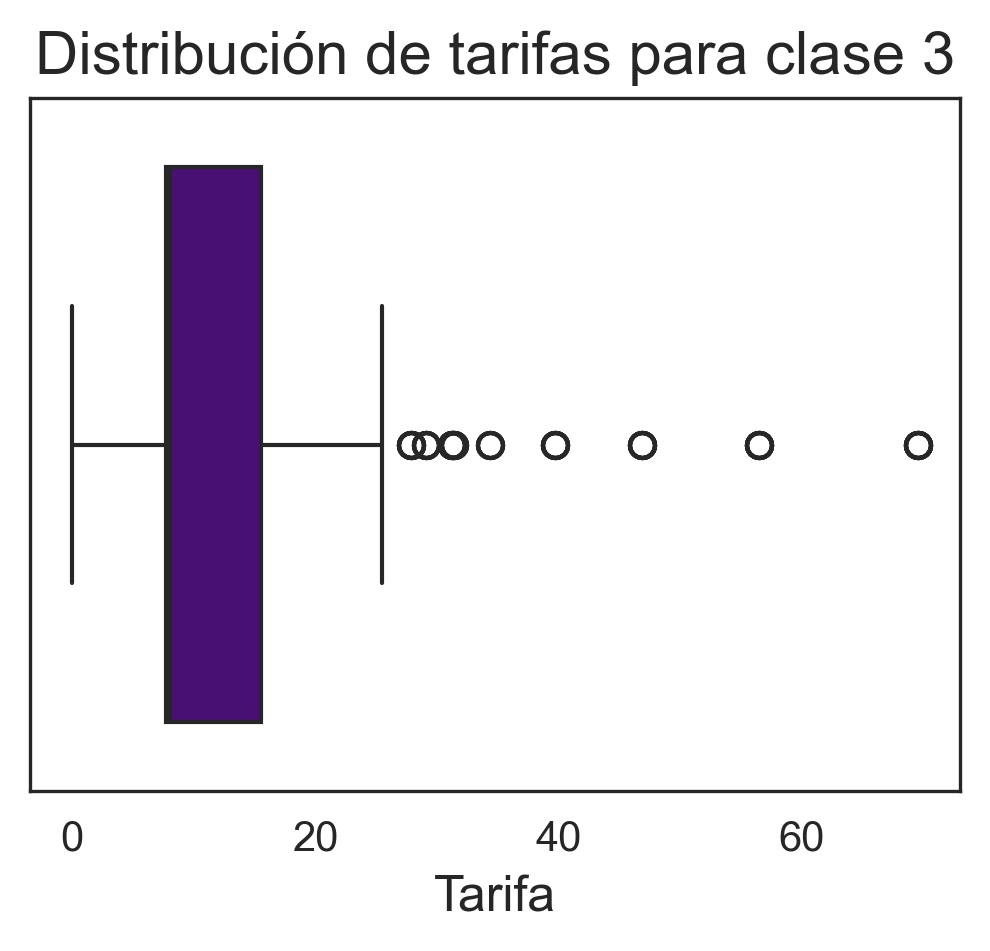

Valor de la mediana para clase 3: 8.05
Valor de la media para clase 3: 13.68


In [267]:
#Figuras por separado
for clasenum in [1, 2, 3]:
    clasee = titanic[titanic["Pclass"] == clasenum]
    plt.figure(figsize=(4,3))
    sns.boxplot(data=clasee, x="Fare", color="indigo")
    plt.xlabel("Tarifa")
    plt.title(f"Distribución de tarifas para clase {clasenum}")
    plt.show()
    print(f"Valor de la mediana para clase {clasenum}: {clasee['Fare'].median():.2f}")
    print(f"Valor de la media para clase {clasenum}: {clasee['Fare'].mean():.2f}")

### Preguntas

- La tarifa parece estar relacionada con la clase? Sí, se ve una relación. Para el histograma general se ve un boxplot más amplio de tarifa para la clase 1, hasta se ven valores extremos con uno de ellos en aproximadamente en 500 dólares. Mientras que en las clases 2 y 3 el rango de cuartiles del boxplot, como Q1 a Q3 estarían no sobrepasando los 100 dólares para valor de tarifa. Por ejemplo, en la clase 3, 2, 1 se tienen medias de 13.68, 20.66 y 84.15 dólares, respectivamente. Mientras que la mediana para la clase 3, 2, 1, es 8.05, 14.25 y 60.29. Donde se ve claramente que la clase 1 paga más valor de tarifa.
- Hay dispersión dentro de cada clase? Sí hay, pues se observa que hay pasajeros de la clase determinada que no paga el mismo precio de tarifa. Por ejemplo al ver en la clase 3, considerando que el promedio es 13.68 dólares hay valores atípicos como el de 66 dólares, aproximadamente, también como el de 47 dólares, o el 58 dólares, entre otros. En la clase 2 casi ni se ven valores atípicos, solo 2 superiores a 60 y puede ser menor a 80 dólares, aunque igual significativos. Luego para la clase 1, hay un valor muy extremo de casi 500 dólares y más entre 200 y 300 dólares. Por tanto, hay variedad de valores atípicos.
- Existen valores extremos? Sí existen, como se había mencionado antes.
- Diría que `Fare` y `Pclass` contienen exactamente la misma información?
No del todo, existe relación entre ellas pero no necesariamente por ejemplo, un pasajero que pague aprox. 65 dólares va a ser de clase 1, 2 o 3, puede ser cualquiera, como ejemplo, no significa que los 65 dólares los pagarán los de clase 1 debido a valor "alto" tanto en media o mediana. También existen en clase 2 y 3 como un aproximado, pero si en menos cantidad. Luego la clase, al final no permite saber si el pasajero pagó más o menos.

### Ahora usted

**1. Compare la distribución de edad entre las tres clases.**

Use un gráfico que permita comparar las distribuciones.

- Los pasajeros tienen edades similares en todas las clases? No en todo, en clase 1 se ve una simetría tendiendo a edades más altas con respecto a la clase 2 y 3. 
- Qué diferencias observa? Como había mencionado la simetría en la clase 1 es notable, bordeando una mediana de 38 años aprox., mientras que para la clase 2 y 3 va tendiendo una asimetría hacia edades más jóvenes con respecto a las de la clase 1. Aunque las clases 2 y 3 presentan valores atípicos rondeando los 70 años. Y valores atípicos a edades mucho más pequeñas solo la clase 2.


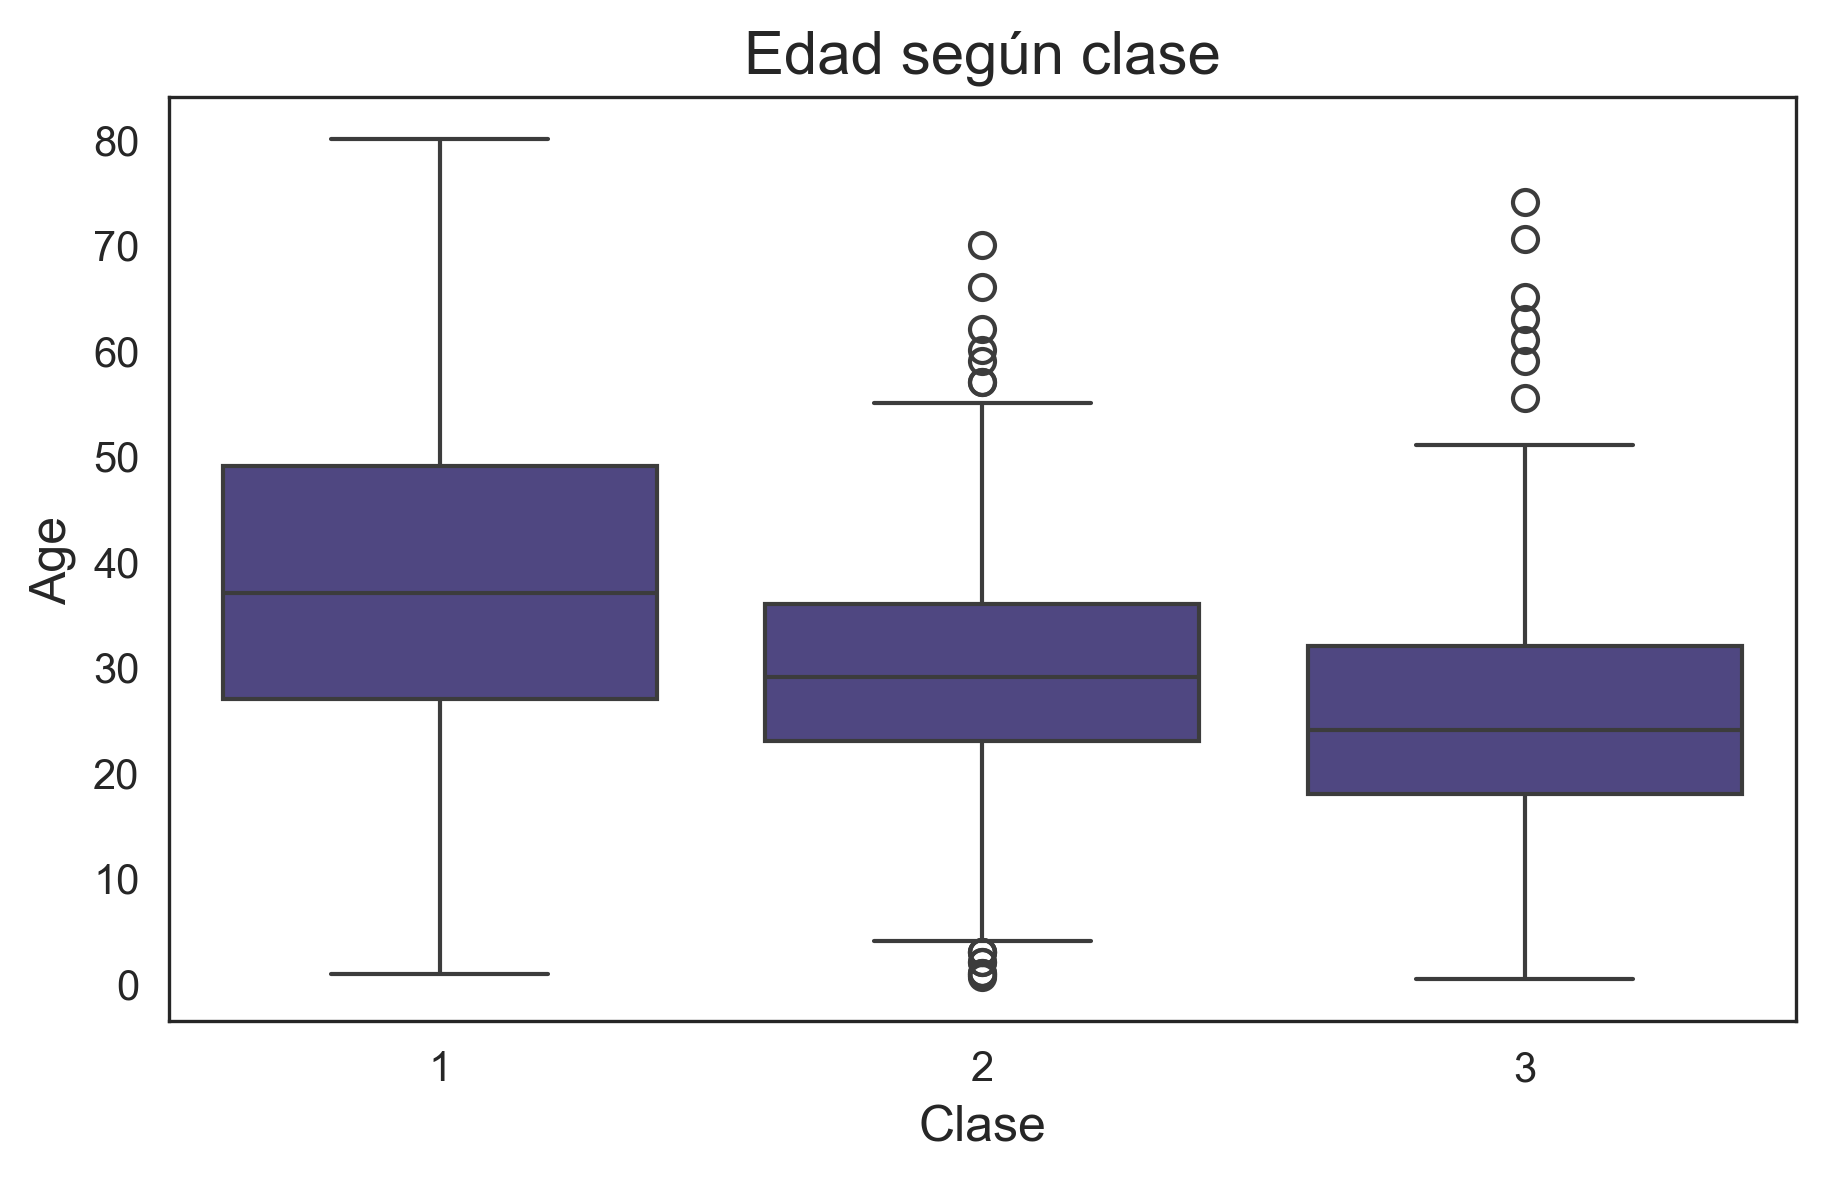

In [268]:
plt.figure(figsize=(7,4))
sns.boxplot(data=titanic, x="Pclass", y="Age", color='darkslateblue')
plt.xlabel("Clase")
plt.ylabel("Age")
plt.title("Edad según clase")
plt.show()

**2. Las características `SibSp` y `Parch` contienen información sobre familiares a bordo.**

Construya una nueva característica llamada `Familia`, que represente el número total de personas del grupo familiar incluyendo al propio pasajero:

\[
Familia = SibSp + Parch + 1
\]


In [269]:
# Complete el código 
titanic["Familia"] = titanic["SibSp"]+titanic["Parch"]+1 #el 1 es el propio pasajero
#1 se consideraría que el pasajero viaja solo
#con el comando siguiente se ordena cantidad según si viajaba solo/a o si viajaba acompañado
titanic["Familia"].value_counts().sort_index()

Familia
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

**3. Explore la nueva característica `Familia`.**

- La mayoría de los pasajeros viajaba sola o acompañada? Como se puede observar, la mayoría de los pasajeros viajaba sola, siendo un 60,26% aproximadamente de la muestra. Mientras que el resto, viajaba acompañada. Luego la tendencia del pasajero es a viajar solo.
- Hay grupos familiares muy grandes? Sí, existen por ejemplo, hay 7 familias conformadas por 11 pasajeros. 
- Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado?
Sí, puede cambiar porque es distinta la relación familiar, por ejemplo 'SibSp' considera hermanos y/o cónyuges, mientras que 'Parch' considera padres e/o hijos a bordo.

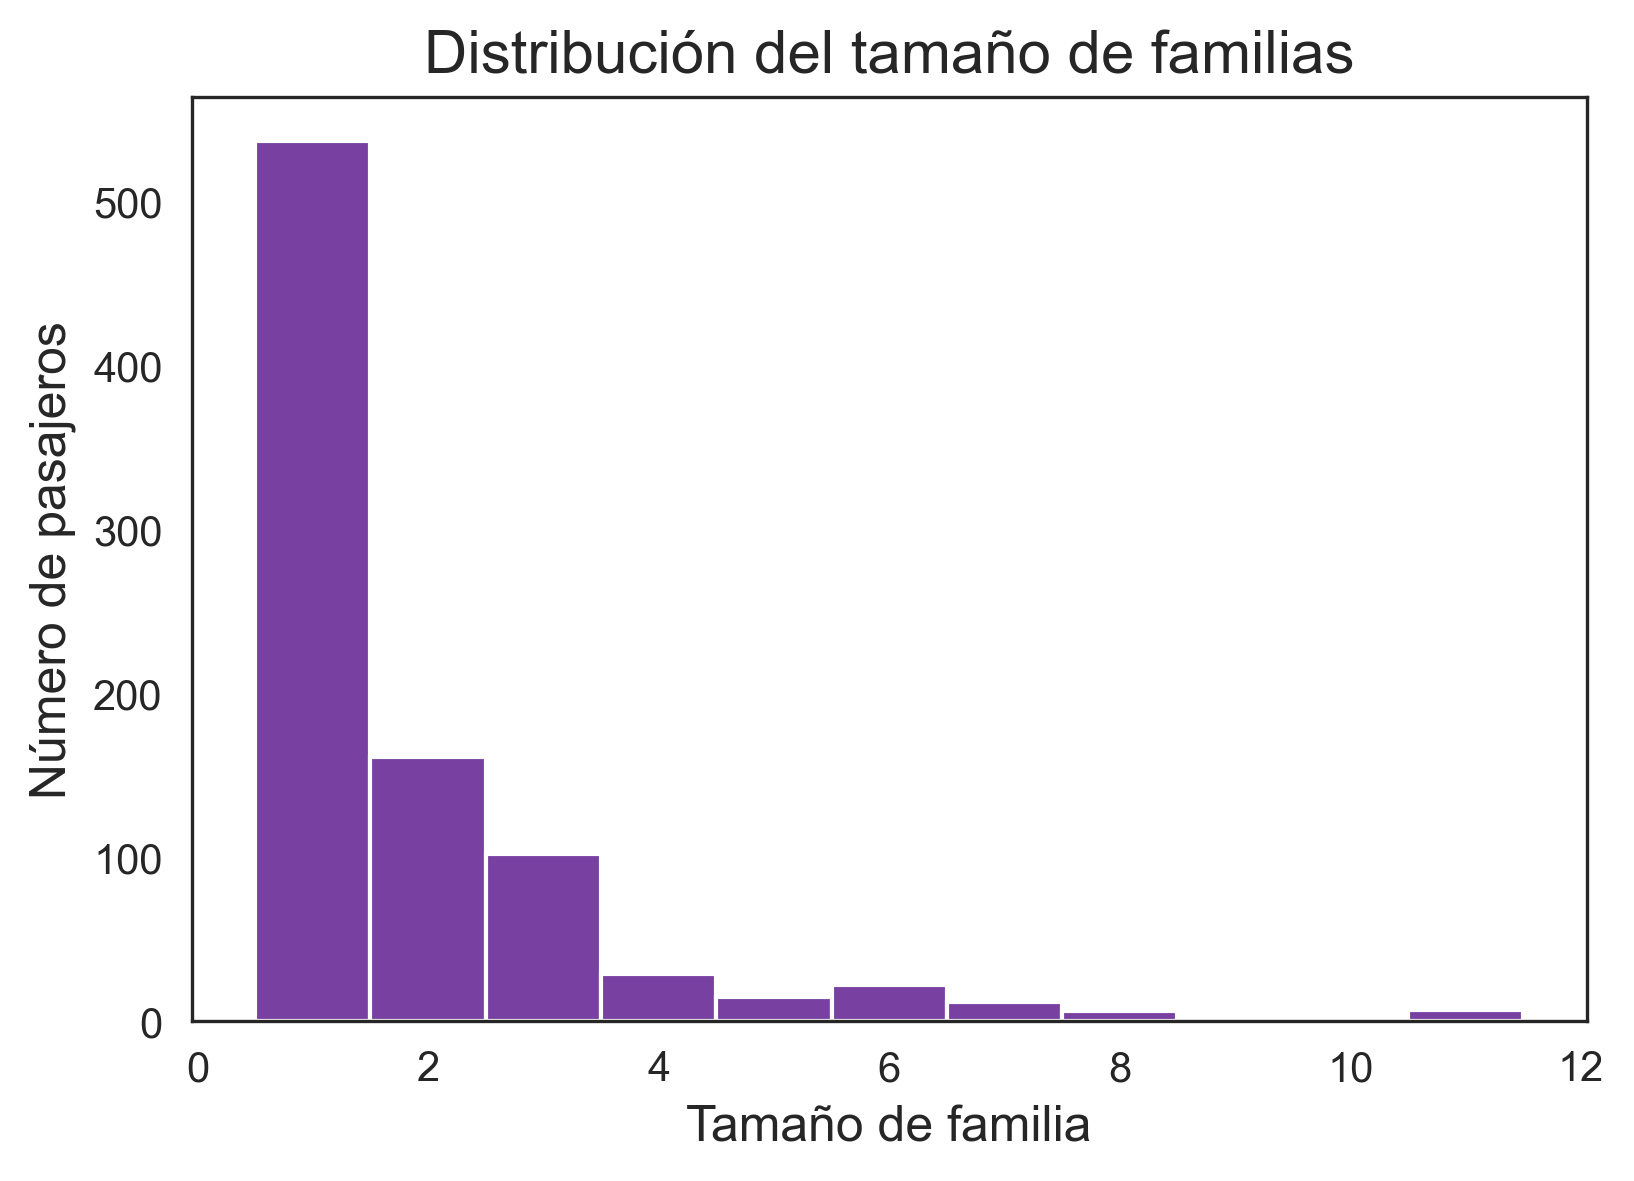

In [270]:
plt.figure(figsize=(6,4))
sns.histplot(data=titanic,x="Familia",color="indigo",discrete=True)
plt.xlabel("Tamaño de familia")
plt.ylabel("Número de pasajeros")
plt.title("Distribución del tamaño de familias")
plt.show()

# Parte 4: Investigar la supervivencia

## ¿Qué características estaban asociadas con la supervivencia?

Ahora incorporaremos `Survived`, la variable que queremos comprender.

Investigaremos si la supervivencia está asociada con características como:

- sexo
- clase
- edad
- tamaño del grupo familiar


### Ejemplo de gráfico: supervivencia según sexo

Como `Survived` toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de pasajeros que sobrevivió**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


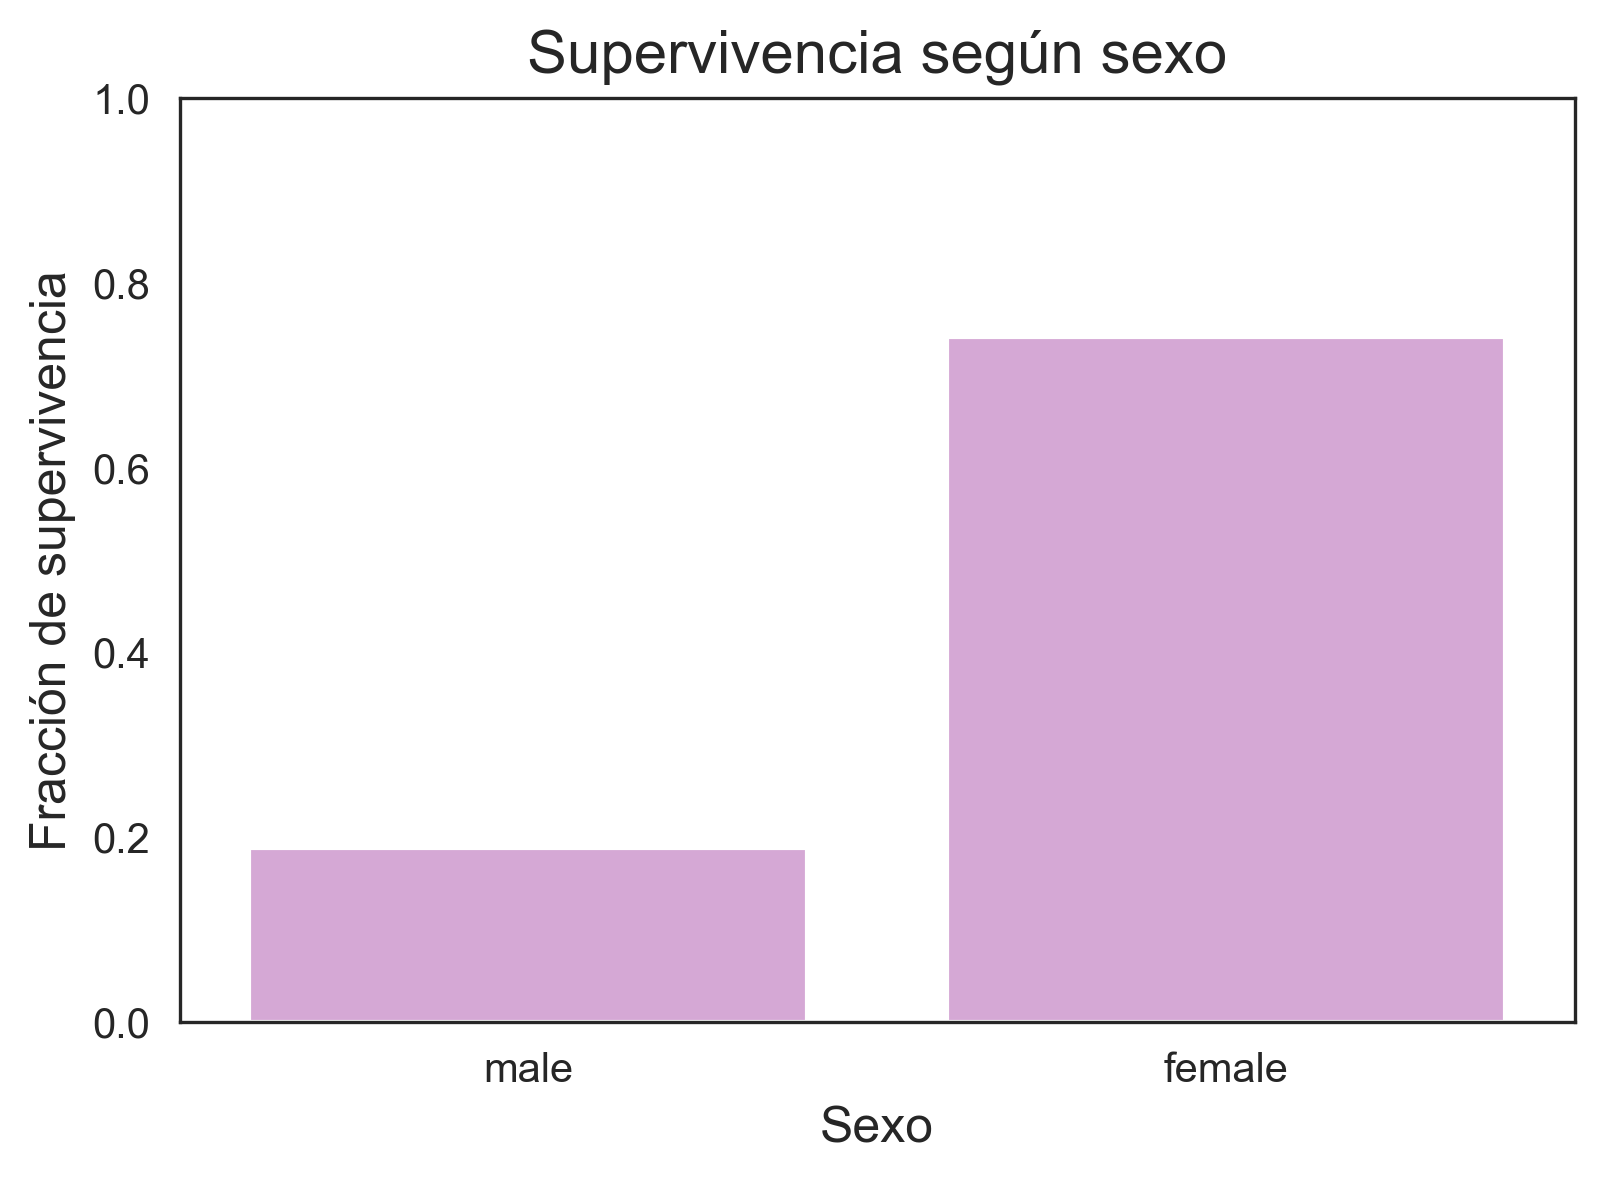

In [271]:
plt.figure(figsize=(6,4))
sns.barplot(data=titanic, x="Sex", y="Survived", errorbar=None, color='plum')
plt.xlabel("Sexo")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según sexo")
plt.ylim(0,1)
plt.show()

### Preguntas

- La fracción de supervivencia es similar para hombres y mujeres? No, no es similar, la fracción de supervivencia es mayor para las mujeres.
- Podemos concluir a partir de este gráfico por qué existe la diferencia?
No se puede concluir sólo del gráfico. (De por sí se tiene una tendencia debido a que se vio la película, pero del gráfico no)

### Ahora usted

**1. Explore la supervivencia según `Pclass`.**

- Hay diferencias entre las tres clases? Sí, si hay diferencias.
- Existe una tendencia? La tendencia de supervivencia presente tiende a ser mayor en la clase 1, luego en la clase 2 y posteriormente para la clase 3.


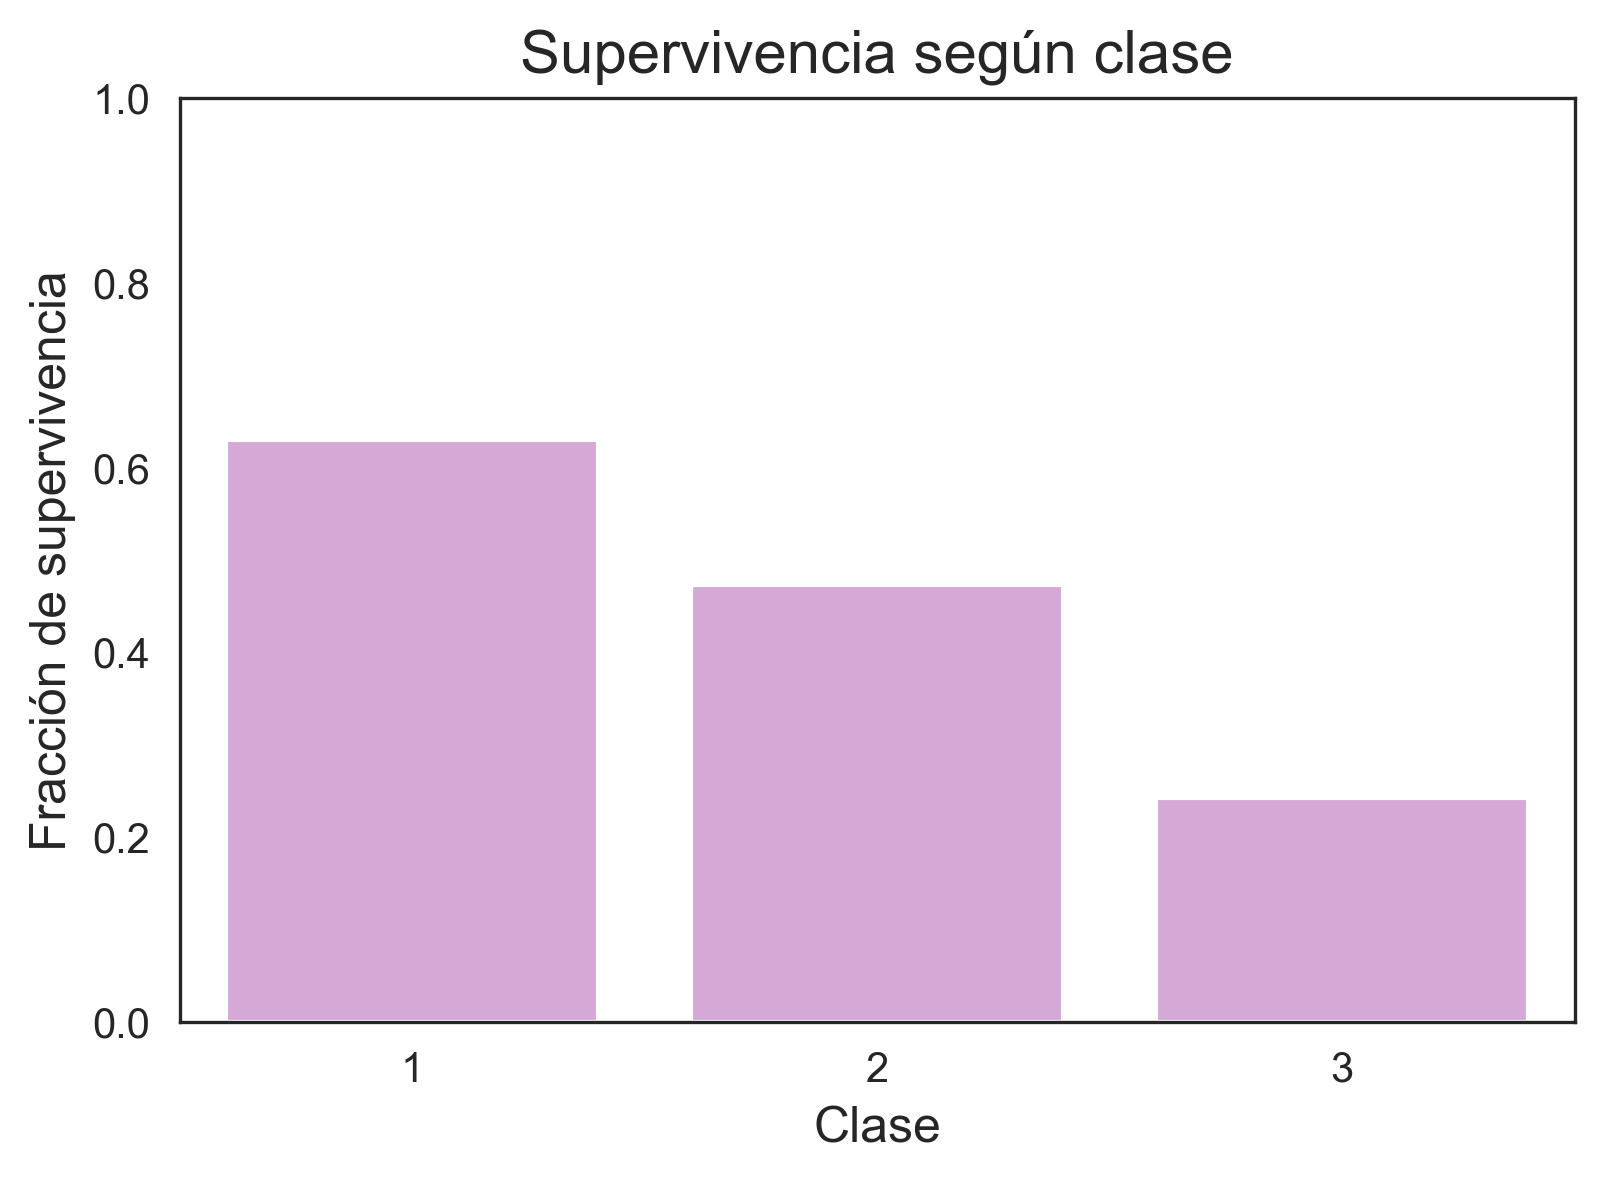

In [272]:
# Escriba aquí su código
plt.figure(figsize=(6,4))
sns.barplot(data=titanic, x="Pclass", y="Survived", errorbar=None, color='plum')
plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase")
plt.ylim(0,1)
plt.show()

**2. Explore la supervivencia según edad.**

Puede comparar las distribuciones de edad de quienes sobrevivieron y quienes no sobrevivieron.

- La edad parece estar asociada con supervivencia? No se ve así, porque claro, hay un mayor fracciónde supervivencia en el rango de edad de 0 a 10 años, pero el segundo grupo con más fracción de supervivencia es el rango de 30 a 40. Y también están las edades de 70 a 80 que sobreviven menos. Hay tendría sentido. Pero en edades más jóvenes, no del todo.
- Hay algún grupo de edad que llame particularmente su atención? Justamente el de 30-40 años, como había mencionado antes. También está el rango de 50 a 60 años, porque es mayor que el de 40 a 50 años.


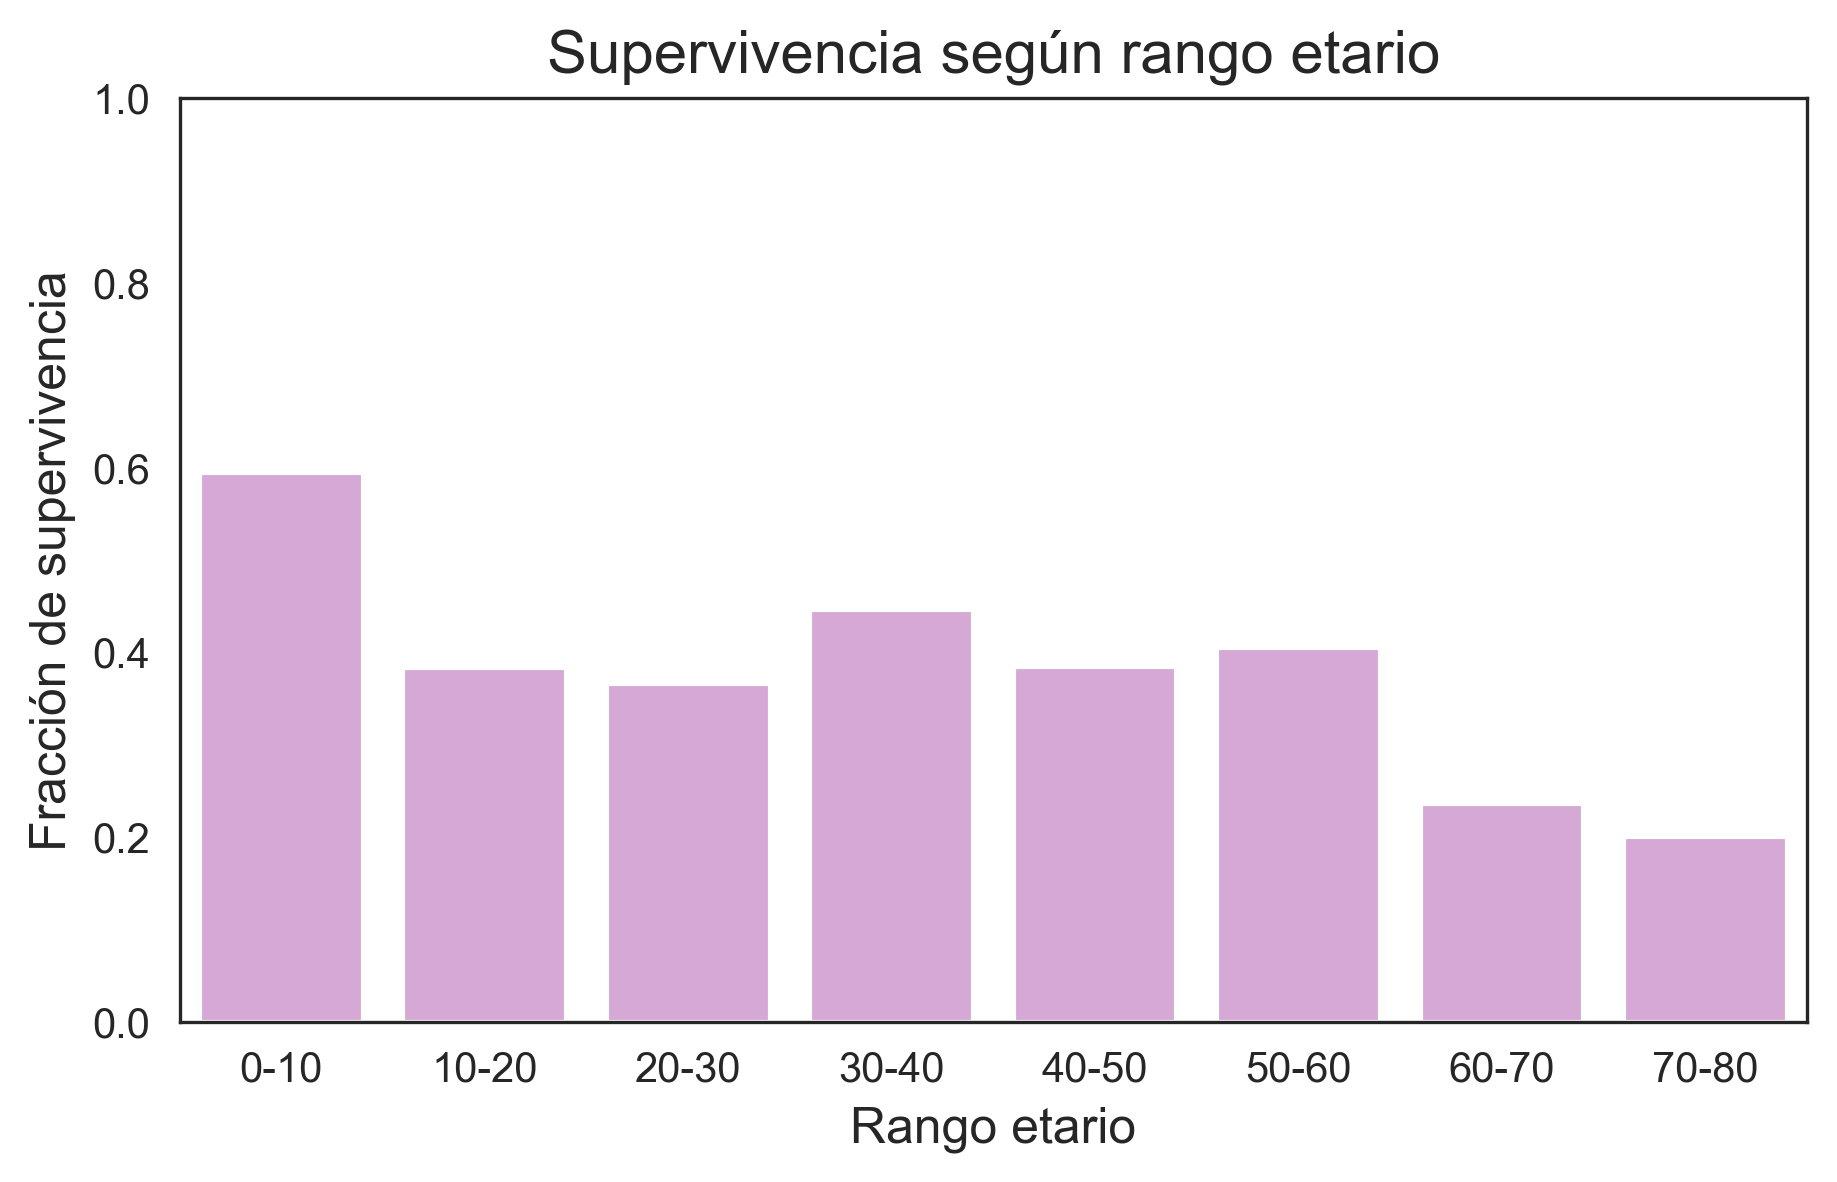

In [273]:
# Escriba aquí su código
#para poder visualizar los datos correctamente, se pueden agrupar por rangos de edades
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
rangos = ["0-10", "10-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80"]
titanic["Rangoedad"] =pd.cut(titanic["Age"],bins=bins,labels=rangos) #esto permite hacer rangos de las edades
plt.figure(figsize=(7,4))
sns.barplot(data=titanic,x="Rangoedad",y="Survived",color="plum",errorbar=None)
plt.xlabel("Rango etario")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según rango etario")
plt.ylim(0, 1)
plt.show()

**3. Explore la supervivencia según `Familia`.**

- Viajar solo parece favorable o desfavorable? Viajar solo parece desfavorable, dado que se observa una menor fracción de sobrevivencia. En lo contrario, hay una mayor fracción de sobrevivencia para los que la familia compone 4 pasajeros.
- La relación parece simple? No, porque la fracción de supervivencia no sigue alguna tendencia en general, es variable. Pero por ejemplo desde la cantidad de 4 pasajeros, a más, lo que compone la familia, disminuye la tendencia de supervivencia hacia 6 pasajeros, pero luego vuelve a aumentar y disminuir.
- Qué ocurre con los grupos familiares grandes? Los grupos familiares grandes presentan menos fracción de supervivencia, aunque no en todos. Y con ello, para familias muy grandes es de desfavorable para poder sobrevivir.


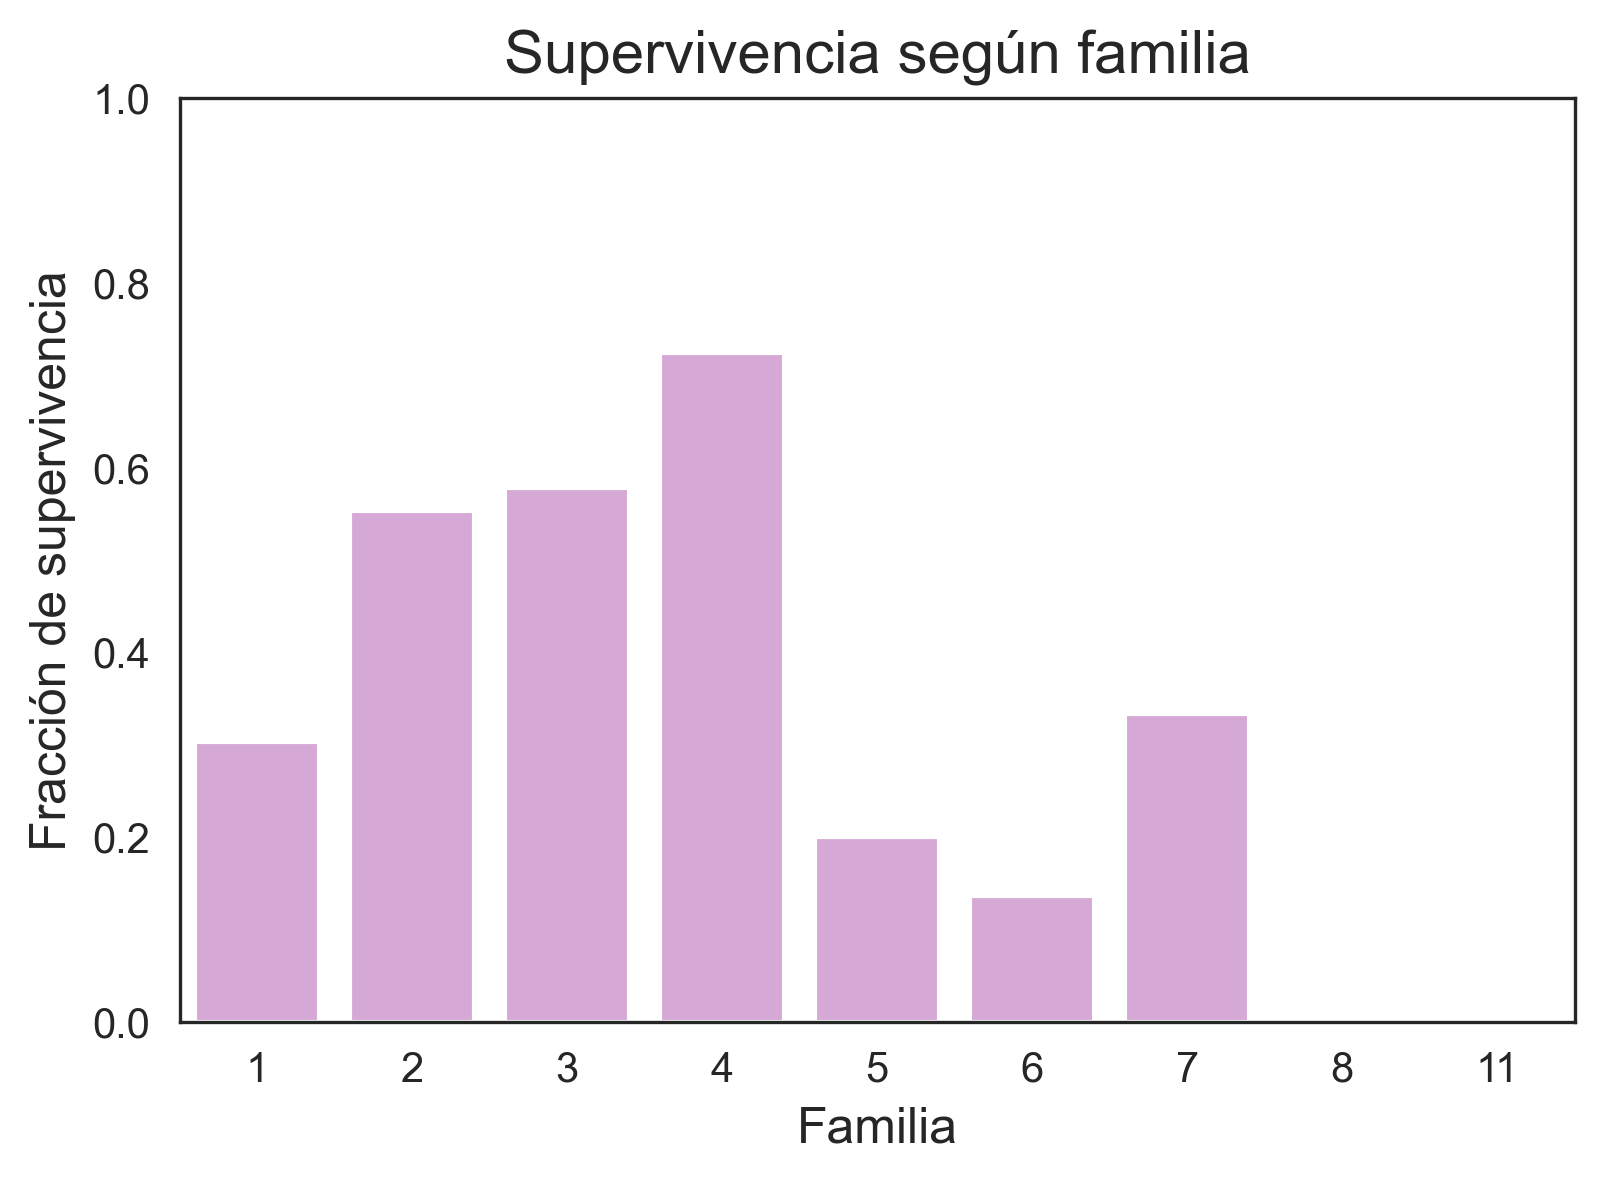

In [274]:
# Escriba aquí su código
plt.figure(figsize=(6,4))
sns.barplot(data=titanic, x="Familia", y="Survived", errorbar=None, color='plum')
plt.xlabel("Familia")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según familia")
plt.ylim(0,1)
plt.show()

# Parte 5: Agregar contexto

## ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra.

Ya estudiamos por separado:

- `Pclass` y supervivencia
- `Sex` y supervivencia

Ahora podemos preguntar:
 **¿La relación entre clase y supervivencia es igual para hombres y mujeres?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


### Ejemplo de gráfico: clase, sexo y supervivencia


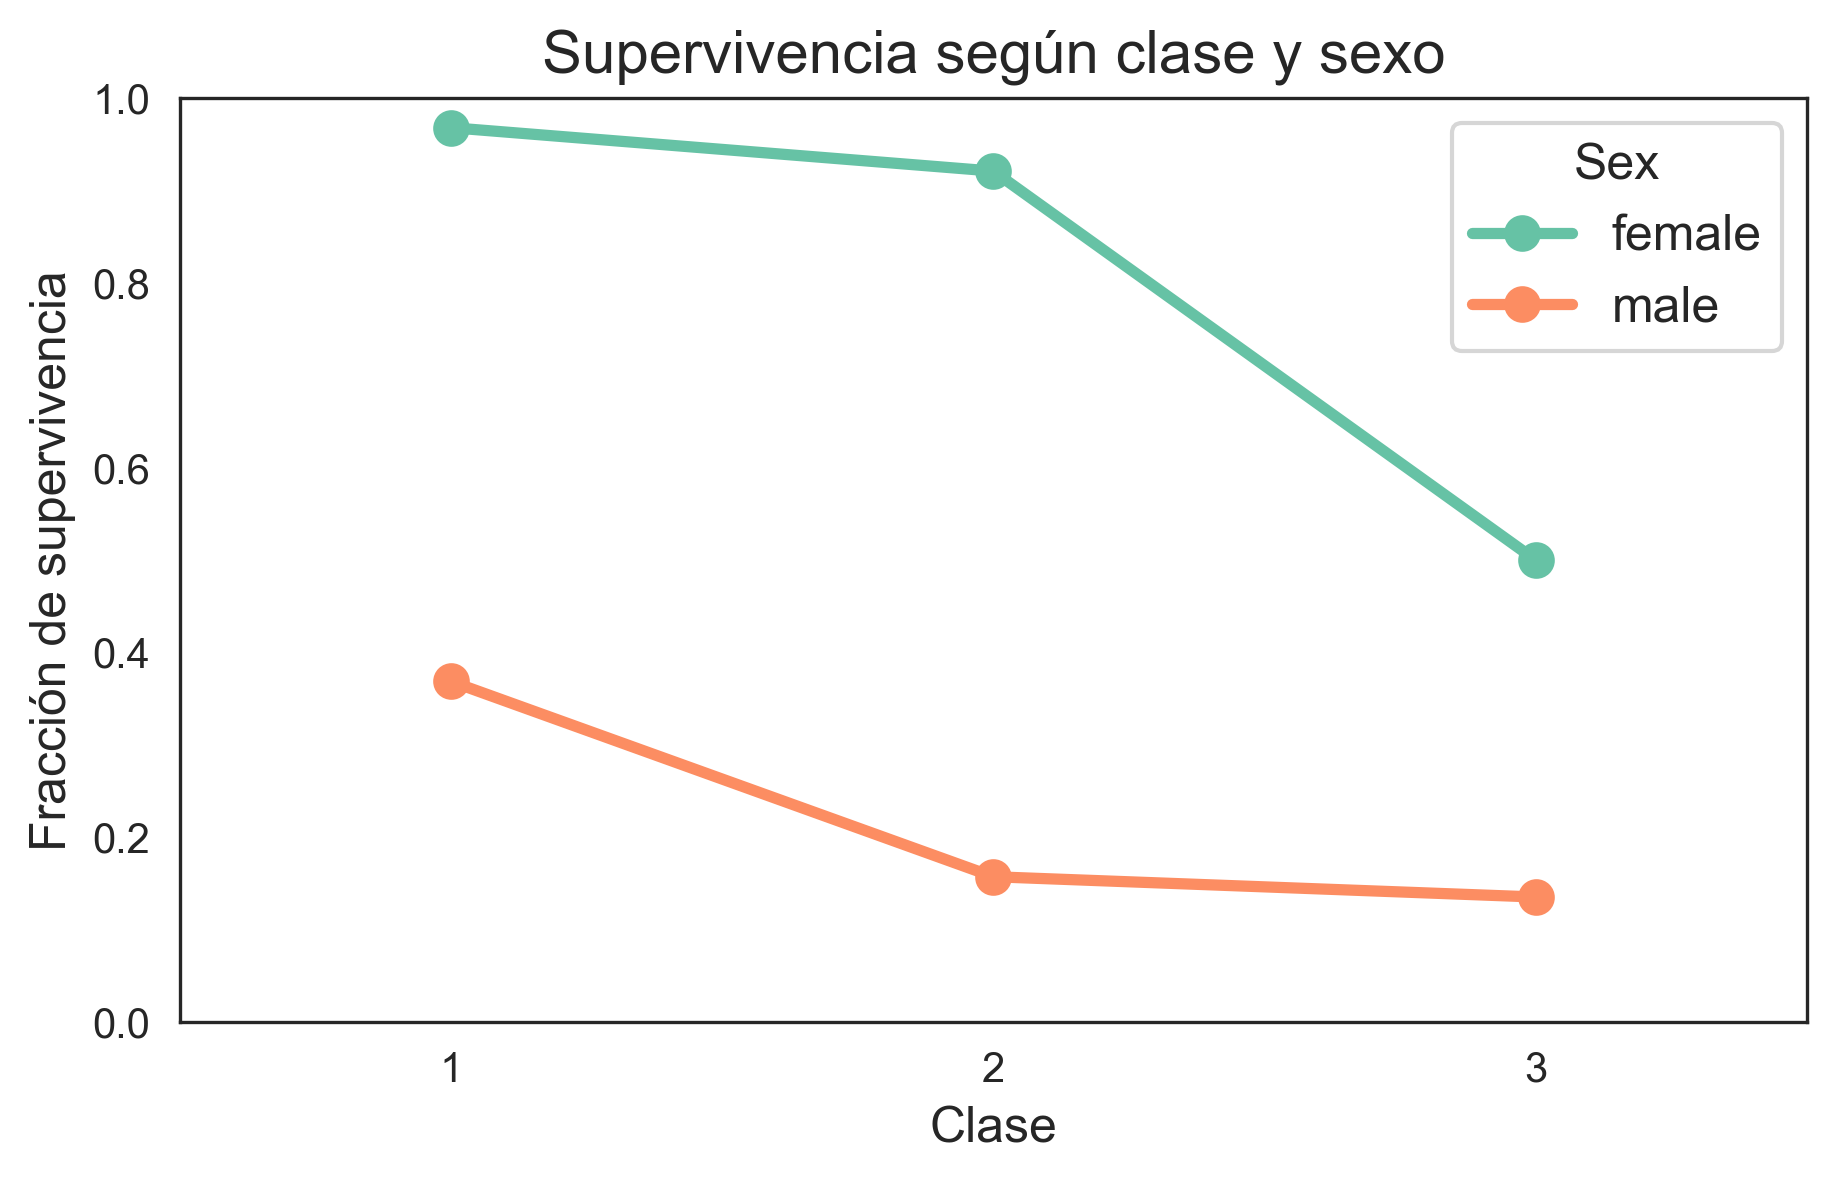

In [275]:
plt.figure(figsize=(7,4))
sns.pointplot(data=titanic,x="Pclass",y="Survived",hue="Sex",palette="Set2",errorbar=None)
plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1)
plt.show()

### Preguntas sobre el ejemplo

- La relación entre clase y supervivencia es igual para hombres y mujeres? No es igual, para los hombres la relación tiende desde aprox. casi 40% de supervivencia y decae a casi 15%. Mientras que para las mujeres la fracción de supervivencia es casi 1.0 (como 100%) y decae a aproximadamente a 50%. Con ello, en general, la fracción de supervivencia es mayor para la clase 1 y menor para la clase 3. Junto al sexo, la fracción de supervivencia en las mujeres de clase 1 es mayor que en los hombres de clase 1, así consecuentemente.
- Qué información se perdía cuando mirábamos solamente `Pclass`? Se perdía el sexo del pasajero, lo que igual es importante para determinar el factor de supervivencia.
- Qué información se perdía cuando mirábamos solamente `Sex`? Se perdía la clase, lo que igual es factor importante de supervivencia.
- Hay algún grupo particularmente favorecido o desfavorecido? El grupo favorecido sería el grupo de las mujeres.

### Ahora usted

**1. Cree una característica `Persona` con tres categorías:**

- `mujer`
- `hombre`
- `niño/a`

Considere como niño/a a un pasajero menor de 16 años.


In [276]:
titanic["Persona"] = ""
for i in range(len(titanic)):
    if titanic.loc[i, "Age"] < 16:
        titanic.loc[i, "Persona"] = "Niño/a"
    elif titanic.loc[i, "Sex"] == "female":
        titanic.loc[i, "Persona"] = "Mujer"
    else:
        titanic.loc[i, "Persona"] = "Hombre"
titanic["Persona"].value_counts()

Persona
Hombre    537
Mujer     271
Niño/a     83
Name: count, dtype: int64

**2. Explore la supervivencia según `Persona` y `Pclass`.**

- Los niños presentan el mismo patrón que los adultos? No, en la clase 2 los niños tienen mayor fracción de supervivencia, no así los adultos.
- La clase sigue siendo importante dentro de cada grupo? No necesariamente, porque por ej. los niños tienen más tendencia de sobrevivencia en clase 2 que en clase 1, luego es clase 3 es menos. 
- Qué combinación de características parece asociarse con la mayor supervivencia? 
El del grupo de niños y clase 2, con una mayor fracción de supervivencia. También el grupo de adultos de clase 3 con menos tasa de supervivencia.

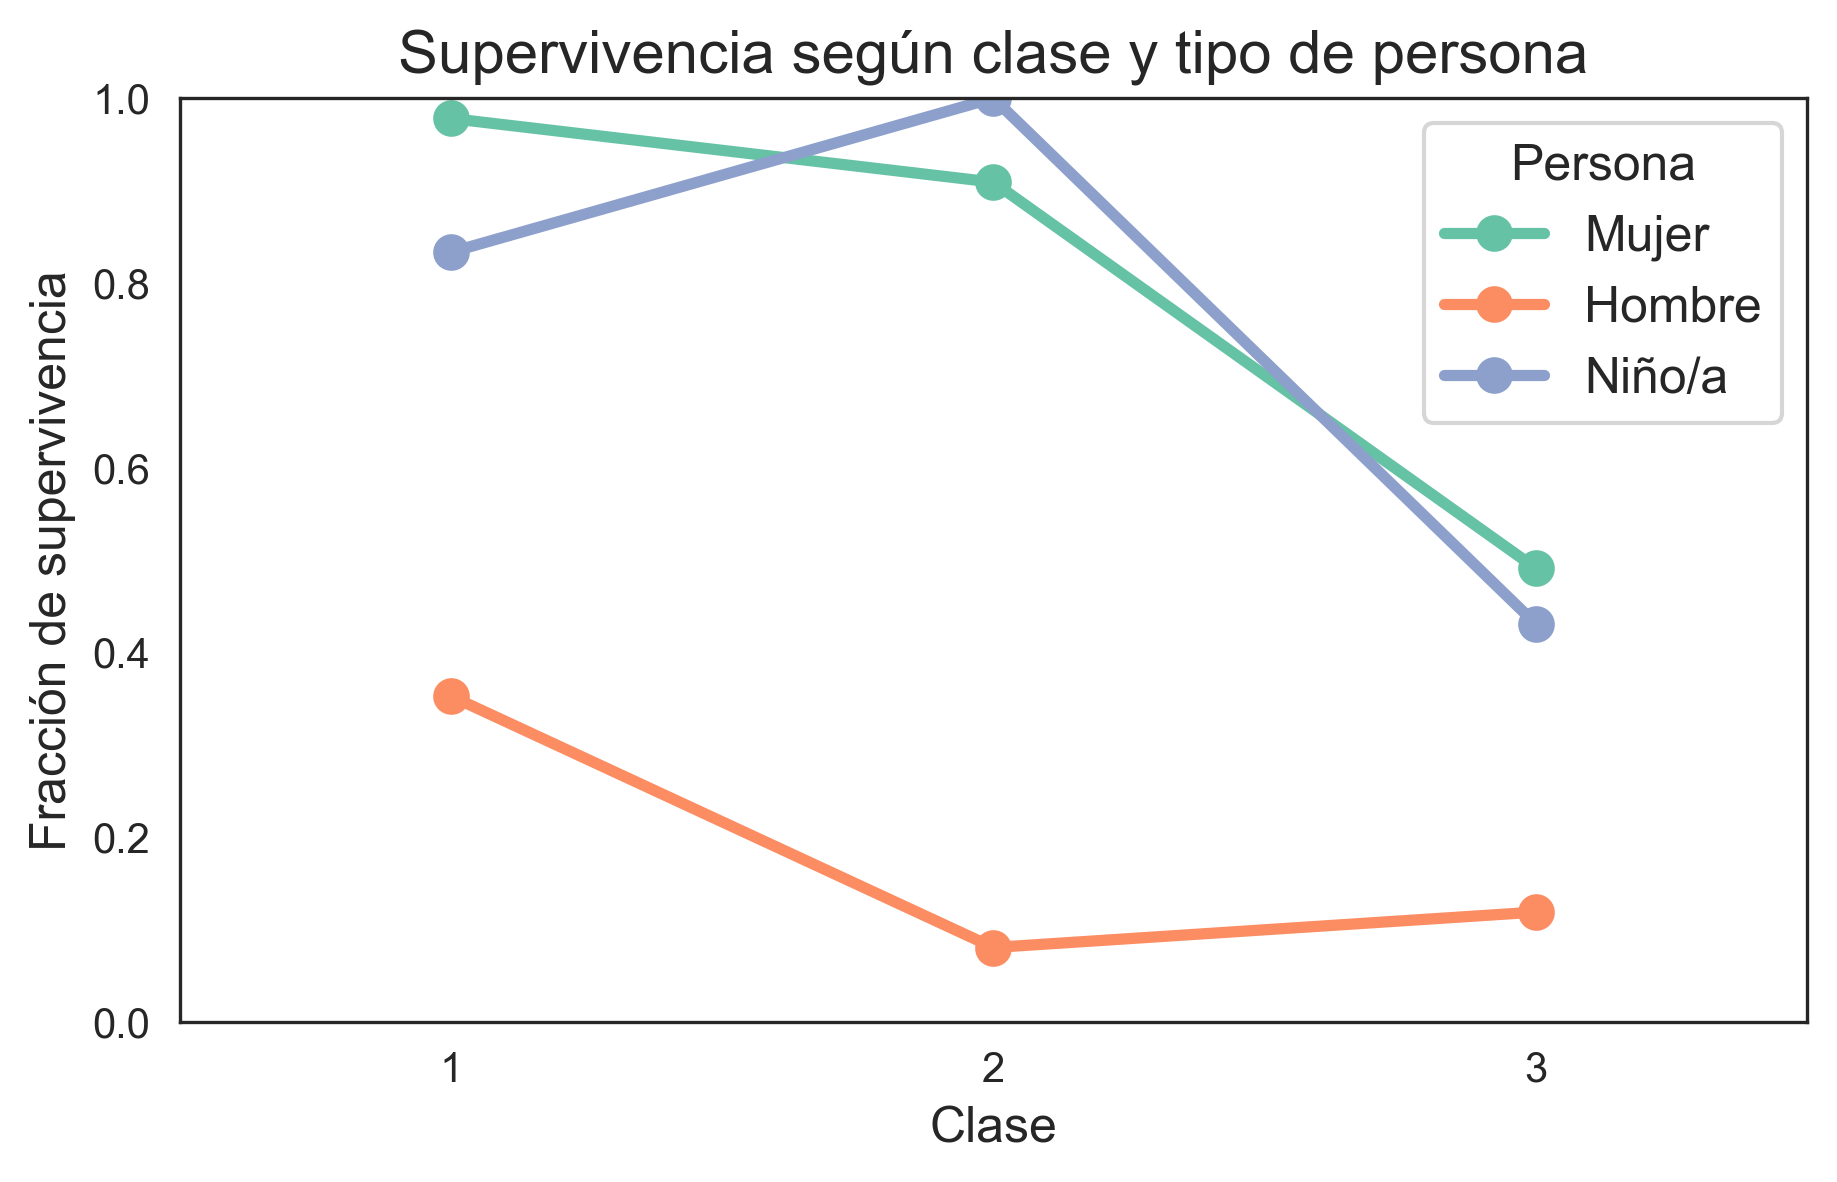

In [277]:
plt.figure(figsize=(7,4))
sns.pointplot(data=titanic,x="Pclass",y="Survived",hue="Persona",errorbar=None,palette="Set2")
plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y tipo de persona")
plt.ylim(0,1)
plt.show()

**3. Elija una relación adicional para explorar incorporando una tercera característica.**

Algunas ideas:

- edad + sexo + supervivencia;
- tamaño de familia + clase + supervivencia;
- puerto de embarque + clase + supervivencia.

No necesita crear una figura complicada. El objetivo es responder una pregunta concreta.

**Escriba primero la pregunta que quiere investigar y luego construya el gráfico.**


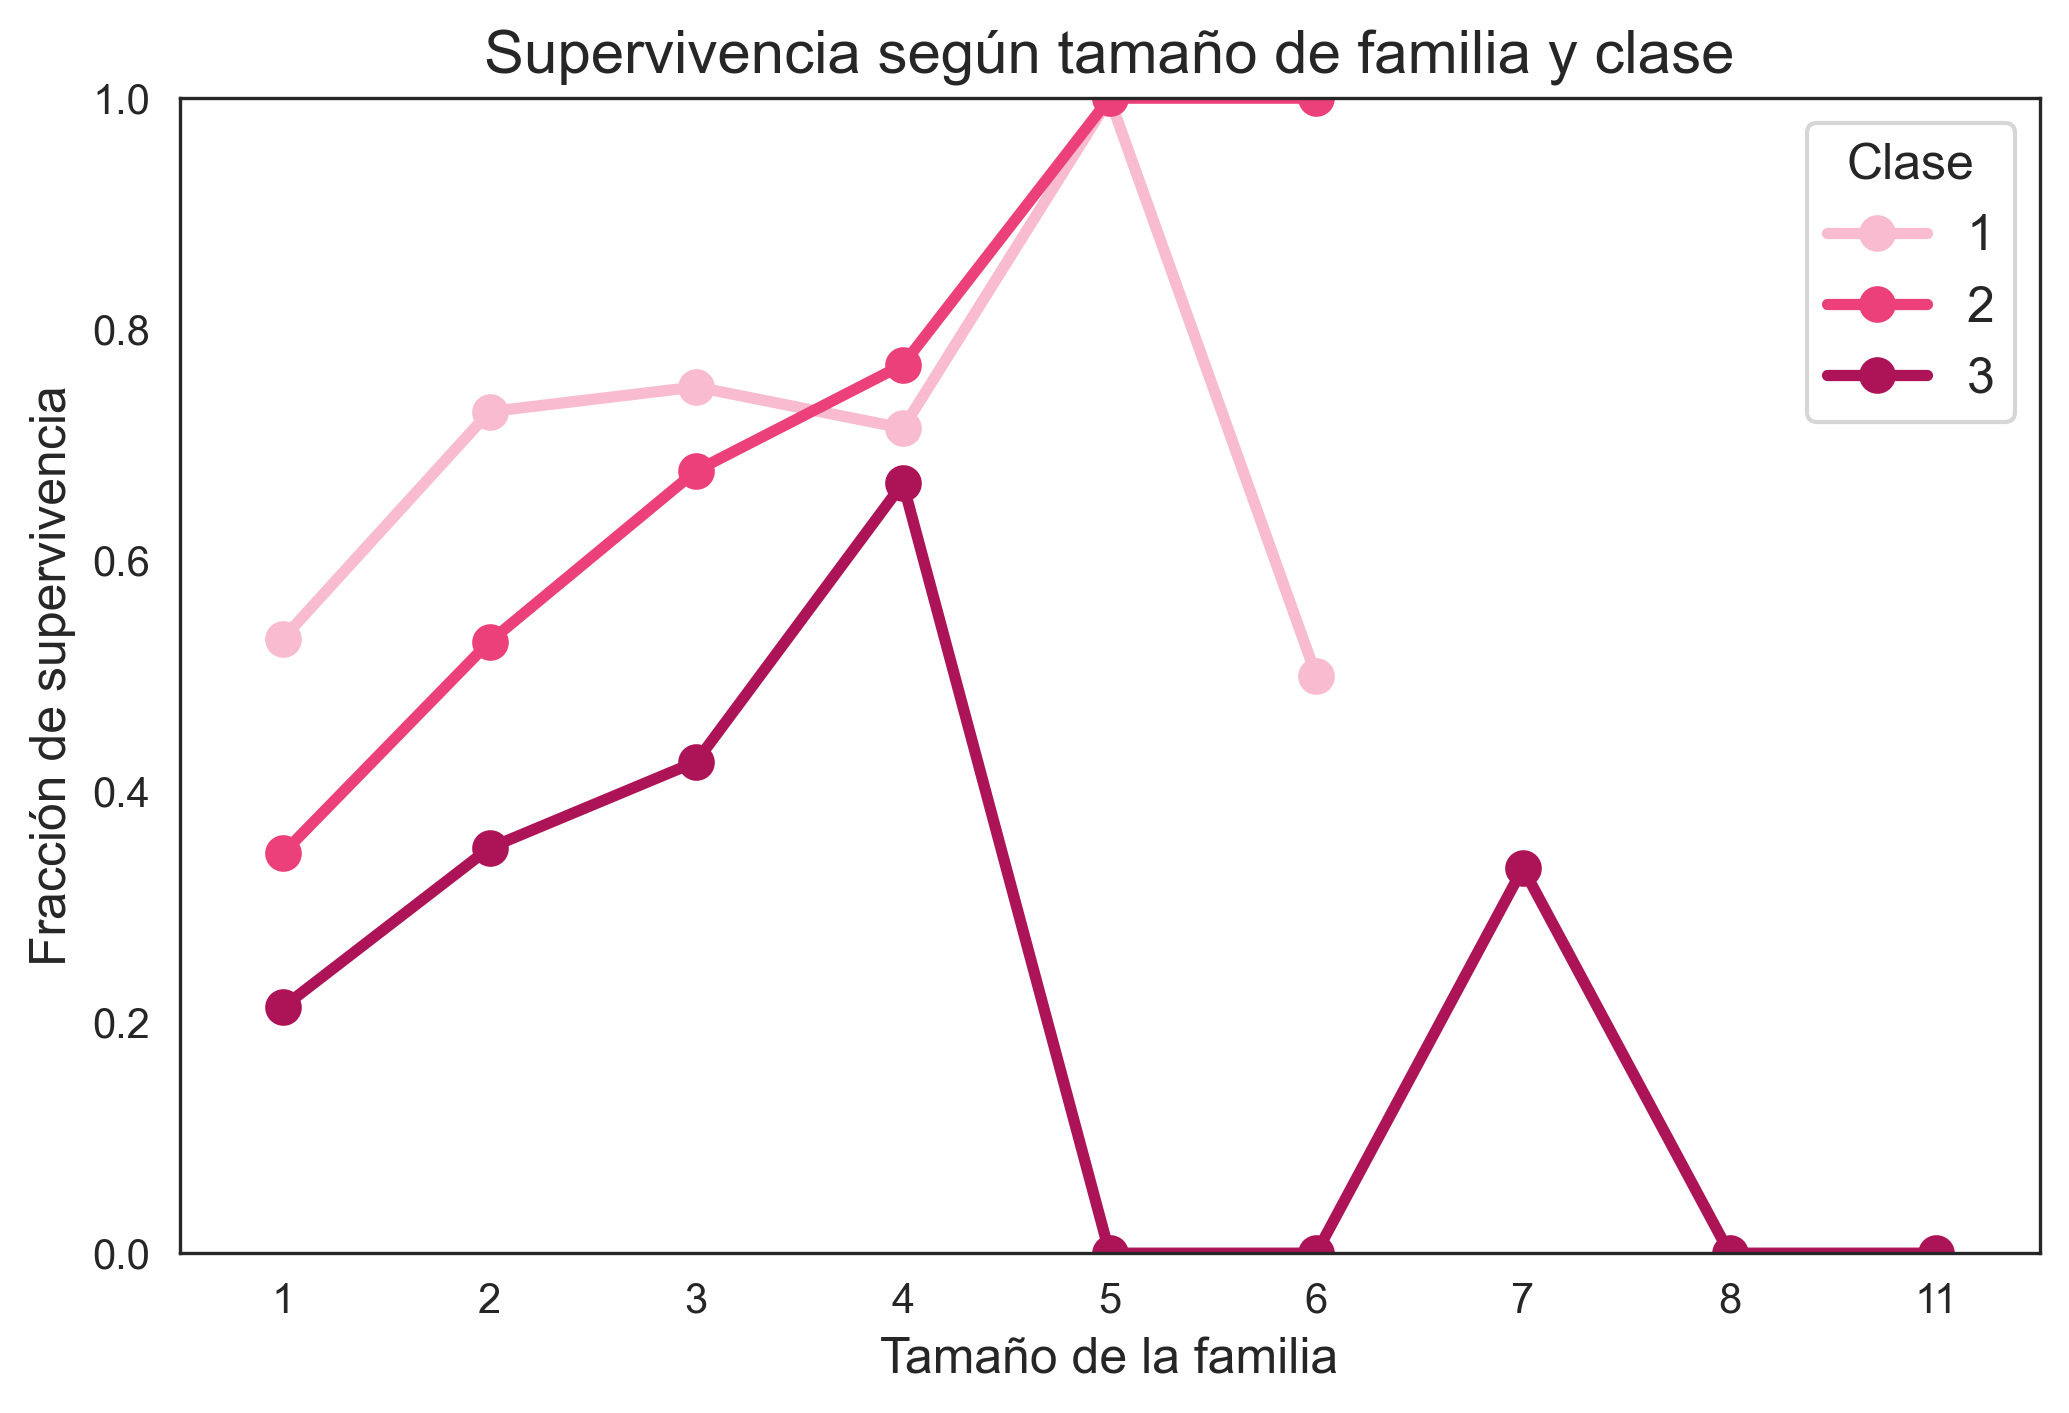

In [278]:
# Pregunta sobre tamaño de familia + clase + supervivencia:
#¿Influye el tamaño de la familia conjunta la clase a la supervivencia?
# Código:
plt.figure(figsize=(8,5))
sns.pointplot(data=titanic,x="Familia",y="Survived",hue="Pclass",errorbar=None,palette=["#F8BBD0", "#EC407A", "#AD1457"])
plt.xlabel("Tamaño de la familia")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según tamaño de familia y clase")
plt.ylim(0, 1)
plt.legend(title="Clase")
plt.show()

En la gráfica se puede observar que hasta el tamaño de la familia de 3 pasajeros la fracción de supervivencia va en aumento para todas las clases. Luego para familias de 3-4 integrantes pertenecientes a la clase 2 y 3 la fracción de supervivencia aumenta, mientras que para la clase 1 disminuye. Luego para la clase 2 y 1 aumenta conjunto 1 integrante más en la familia y disminuye considerablemente para la clase 3. Luego en variaciones, la clase 3 es la que menos sobrevive con diversos integrantes en la familia mientras que en la clase 1 disminuye para de 5 a 6 integrantesque, y por último para la clase 2,las familias tienden a sobrevivir conjunto al aumento de sus integrantes.

# Parte 6: Conclusión

## ¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

Por ejemplo:

> **Observación:** las mujeres presentan una mayor fracción de supervivencia que los hombres.

- **Podemos concluir, solo a partir de esta base de datos, que durante la evacuación se dio prioridad a mujeres y niños?** No se puede concluir, porque no hay algún tiempo por ejemplo que diga cuando se evacuaron determinadas personas. O edades, etc.
- **Qué información adicional necesitaríamos para evaluar esa hipótesis?** Podría ser lo del tiempo, como hora a la que se evacuó mujeres y niños, cuántas mujeres o niños, o también hombres en determinado bote para poder concluir la prioridad. Solo uno asume que fue así, para las mujeres y niños, pero con las gráficas no se puede asumir eso.
- **Qué otras explicaciones podrían producir el mismo patrón de supervivencia?** La clase a la que pertenecían, por ejemplo para la clase 1 o 2, o la edad pero se requiere más información para ello.

## Síntesis del análisis

Revise todas las figuras construidas y responda:

### 1. Quiénes eran los pasajeros del Titanic?

Describa brevemente la muestra considerando, al menos:

- sexo
- clase
- edad
- tamaño de familia.

Los pasajeros del Titanic eran 891, entre hombres, mujeres y niños, todos con edades variadas, pero con una tendencia entre 20 a 40 aproximadamente y viajaban en distintas clases (podían ser 1, 2 o 3). Además, habían pasajeros en su mayoría viajando solos o acompañados en familia, pero esto fue menos frecuente. 
### 2. Qué características estaban asociadas con la supervivencia?

Considere:

- sexo
- clase
- edad
- viajar solo o acompañado.

El sexo, donde las mujeres tienden a sobrevivir más, la clase también, pues considerando solo ella, la clase 1 tiende a sobrevivir más, la edad no necesariamente es un factor porque hay variedad de si es el pasajero es más joven o de más edad puede sobrevivir igualmente, debido a que no se observó una relación constante, y por último viajar solo o acompañado podría ser un factor considerándose quizás notable en la clase 2 con el aumento de familiares. Entonces viajar acompañado aumento un poco la posibilidad de supervivencia, pero no necesariamente sería del todo representativo en el caso.
### 3. Qué relaciones cambiaron al considerar varias características al mismo tiempo?
Por ejemplo con respecto a las personas y clase correspondiente, la tendencia cambia a partir de la clasificación de niños y adultos con ello mujeres y hombres, siendo diferentes para las clases.
### 4. Encontró características que contienen información relacionada?
Sí, ejemplos de ello son la relación entre la clase y el sexo como factores más notables para la supervivencia. Pero otras características como la familia o la edad podrían otorgar más información para ver si se tiende a sobrevivir o no, aunque es más para el tamaño de la familia.
### 5. Qué resultado le pareció más inesperado?
Que la clase 2 tuviera más posibilidad de supervivencia que la clase 1, por ejemplo. También la cantidad de la familia, puesto que viajar solo o con el grupo muy grande de personas disminuye la posibilidad de supervivencia con respecto a tamaños de familia medianos.

# Conclusión final

## ¿Cuál es el perfil del pasajero típico que sobrevivió?

A partir de **sus propios resultados**, escriba una conclusión breve que caracterice al pasajero con mayor probabilidad de haber sobrevivido en esta muestra.

Considere, cuando corresponda:

- sexo
- edad
- clase
- tamaño del grupo familiar
- otras características que hayan resultado relevantes

Su respuesta debe estar respaldada por las figuras que construyó.


### Escriba aquí su conclusión
Probablemente sobrevivieron más las mujeres con edades entre 20-35 años pertenecientes a la clase 2 cuya familia tenga 2 a 3 personas más, es decir, un total de 3 a 4 integrantes. Luego en general, entre las características que generó más impacto probablemente fue el sexo y la clase, quizás las mujeres y niños pudieron sobrevivir más considerando que fueran de clase 1 o 2, puesto que los hombres sobrevivieron menos.